# Constructing a Station-Level Statistical Manifold from Pedestrian Trajectories

## Design notes

### What is a point on M_U?
In Article 3 we fixed a distribution family for each of 8 trajectory features at Shinjuku.  
In this notebook each **measurement location (station)** becomes a single point on the statistical manifold M_U.  
A point = the vector of fitted distribution parameters across all 8 features:

| Feature | Distribution | Parameters |
|---|---|---|
| `real_speed_mean` | Normal | (μ, σ) |
| `real_speed_cv` | Log-normal | (s, loc, scale) |
| `real_accel_abs_mean` | Half-normal | (loc, σ) |
| `stop_ratio` | Beta | (α, β) |
| `real_straightness` | Beta | (α, β) |
| `speed_skew` | Gamma | (a, loc, scale) |
| `decel_ratio` | Beta | (α, β) |
| `duration_sec` | Log-normal | (s, loc, scale) |

### Dual flat structure of M_U
Each distribution in the schema belongs to an exponential family.  
The product of independent exponential families is itself an exponential family,  
so M_U inherits a **dually flat structure** with:

- **θ-coordinates** (natural parameters): define the e-connection  
- **η-coordinates** (expectation parameters): define the m-connection  
- These are related by a Legendre transform via the log-partition function ψ(θ)

This gives us:
- **e-geodesic**: straight line in θ-space — mixture path in exponential family sense
- **m-geodesic**: straight line in η-space — mixture path in mean-parameter sense
- **KL divergence**: D(p‖q) = ψ(θ_q) - ψ(θ_p) - ⟨η_p, θ_q - θ_p⟩
- **Pythagorean theorem**: D(p‖r) = D(p‖q) + D(q‖r) when m-geodesic p→q ⊥ e-geodesic q→r

The block-diagonal Fisher information (one block per feature) makes all computations tractable.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import stats
from scipy.stats import norm, lognorm, halfnorm, gamma, beta as beta_dist
from scipy.special import digamma, polygamma
from pathlib import Path

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

H_REAL   = 1.7    # assumed human height [m]
STOP_MS  = 0.3    # near-stop threshold [m/s]
BASE_DIR = Path('..')
OUTPUT_DIR = BASE_DIR / 'output' / 'analysis' / 'manifold_stations'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Station configuration

In [2]:
with open(BASE_DIR / 'stations.json', encoding='utf-8') as f:
    ALL_STATIONS = json.load(f)

# Use only stations with analysis.json available
STATIONS = {k: v for k, v in ALL_STATIONS.items() if v['status'] == 'analysis_ready'}
print(f"Stations available: {list(STATIONS.keys())}")
print(f"Pending (no tracking yet): {[k for k,v in ALL_STATIONS.items() if v['status'] != 'analysis_ready']}")

Stations available: ['ginza1', 'ginza2', 'shinjuku', 'kamata', 'shinbashi']
Pending (no tracking yet): []


## 2. Feature extraction

Same function as Article 3. Extracts 8 depth-normalized features per trajectory track.

In [3]:
def extract_features(track, min_points=4):
    traj = track.get('trajectory', [])
    if len(traj) < min_points:
        return None

    times        = np.array([p['time_sec']                for p in traj])
    xs           = np.array([p['x']                       for p in traj])
    ys           = np.array([p['y']                       for p in traj])
    bbox_heights = np.array([p.get('bbox_height', np.nan) for p in traj])

    px_dists  = np.sqrt(np.diff(xs)**2 + np.diff(ys)**2)
    dts       = np.maximum(np.diff(times), 1e-6)

    has_bbox = not np.any(np.isnan(bbox_heights))
    if not has_bbox:
        return None  # require bbox_height for depth normalization

    avg_h       = np.maximum((bbox_heights[:-1] + bbox_heights[1:]) / 2, 1)
    scales      = H_REAL / avg_h
    real_dists  = px_dists * scales
    real_speeds = real_dists / dts

    real_speed_mean = float(np.mean(real_speeds))
    real_speed_std  = float(np.std(real_speeds))
    real_speed_cv   = real_speed_std / real_speed_mean if real_speed_mean > 1e-6 else 0.0
    real_dist_total = float(np.sum(real_dists))
    stop_ratio      = float(np.mean(real_speeds < STOP_MS))
    speed_skew      = float(stats.skew(real_speeds))

    sc0 = H_REAL / max(bbox_heights[0],  1)
    sc1 = H_REAL / max(bbox_heights[-1], 1)
    avg_sc            = (sc0 + sc1) / 2
    real_displace     = float(np.sqrt(((xs[-1]-xs[0])*avg_sc)**2 + ((ys[-1]-ys[0])*avg_sc)**2))
    real_straightness = real_displace / real_dist_total if real_dist_total > 1e-6 else 1.0

    if len(real_speeds) >= 2:
        dts2                = np.maximum((dts[:-1] + dts[1:]) / 2, 1e-6)
        accels              = np.diff(real_speeds) / dts2
        real_accel_abs_mean = float(np.mean(np.abs(accels)))
        decel_ratio         = float(np.mean(accels < 0))
    else:
        real_accel_abs_mean = np.nan
        decel_ratio         = np.nan

    if len(px_dists) < 2:
        return None

    return dict(
        id                  = track['id'],
        real_speed_mean     = real_speed_mean,
        real_speed_cv       = real_speed_cv,
        real_accel_abs_mean = real_accel_abs_mean,
        stop_ratio          = stop_ratio,
        real_straightness   = real_straightness,
        speed_skew          = speed_skew,
        decel_ratio         = decel_ratio,
        duration_sec        = float(times[-1] - times[0]),
        n_points            = len(traj),
    )

In [4]:
# Load and extract features for all stations
station_dfs = {}

for key, s in STATIONS.items():
    path = BASE_DIR / s["analysis_json"]
    start_sec = s.get("start_sec", 0)

    with open(path, encoding="utf-8") as f:
        data = json.load(f)

    # Filter tracks: skip any track whose first point is before start_sec
    # (removes the no-message period for stations like shinbashi)
    tracks = data["tracks"]
    if start_sec > 0:
        tracks = [t for t in tracks
                  if t.get("trajectory") and t["trajectory"][0]["time_sec"] >= start_sec]
        print(f"{key:10} : start_sec={start_sec}s — {len(data["tracks"])} to {len(tracks)} tracks after filter")

    records = [r for r in (extract_features(t) for t in tracks) if r is not None]
    df = pd.DataFrame(records).dropna(subset=["real_speed_mean", "real_accel_abs_mean"])
    station_dfs[key] = df
    print(f"{key:10} ({s["name_ja"]:8}) : {len(df):4d} tracks with bbox_height")


ginza1     (銀座一丁目   ) :  618 tracks with bbox_height
ginza2     (銀座二丁目   ) :  517 tracks with bbox_height
shinjuku   (新宿      ) :  989 tracks with bbox_height
kamata     : start_sec=60s — 973 to 745 tracks after filter
kamata     (蒲田      ) :  745 tracks with bbox_height
shinbashi  : start_sec=60s — 1383 to 1106 tracks after filter
shinbashi  (新橋      ) : 1106 tracks with bbox_height


## 3. Distribution schema (fixed from Article 3)

The distribution families were selected in Article 3 via KS test on Shinjuku data.  
We apply the **same schema** to all stations — no re-selection per station.  
This is essential: changing the family per station would make the manifold coordinates incomparable.

In [5]:
# Fixed distribution schema from Article 3
# Each entry: feature -> (dist_name, scipy_dist, fit_kwargs, preprocessing)
# preprocessing: 'positive' clips at q=0.99 and keeps >0
#                'bounded'  clips to [0.001, 0.999]
#                'positive_skew' keeps >0 (for speed_skew which is mostly positive)

MANIFOLD_SCHEMA = [
    ('real_speed_mean',     'Normal',     norm,      {},                        'positive'),
    ('real_speed_cv',       'Log-normal', lognorm,   {'floc': 0},               'positive'),
    ('real_accel_abs_mean', 'Half-normal',halfnorm,  {'floc': 0},               'positive'),
    ('stop_ratio',          'Beta',       beta_dist, {'floc': 0, 'fscale': 1},  'bounded'),
    ('real_straightness',   'Beta',       beta_dist, {'floc': 0, 'fscale': 1},  'bounded'),
    ('speed_skew',          'Gamma',      gamma,     {'floc': 0},               'positive_skew'),
    ('decel_ratio',         'Beta',       beta_dist, {'floc': 0, 'fscale': 1},  'bounded'),
    ('duration_sec',        'Log-normal', lognorm,   {'floc': 0},               'positive'),
]

FEATURE_NAMES = [f for f, *_ in MANIFOLD_SCHEMA]
print("Manifold features:", FEATURE_NAMES)
print(f"Total features: {len(FEATURE_NAMES)}")

Manifold features: ['real_speed_mean', 'real_speed_cv', 'real_accel_abs_mean', 'stop_ratio', 'real_straightness', 'speed_skew', 'decel_ratio', 'duration_sec']
Total features: 8


## 4. Per-station distribution fitting → manifold coordinates

Each station maps to a point in the product parameter space:
$$\mathbf{p}_{\text{station}} = (\mu_{speed}, \sigma_{speed}, s_{cv}, \ldots, s_{dur}, \text{scale}_{dur}) \in M_U$$

In [6]:
def prep_series(series, prep_type):
    d = series.dropna()
    if prep_type == 'bounded':
        return d.clip(0.001, 0.999)
    elif prep_type == 'positive_skew':
        d = d[d > 0]
        return d[d < d.quantile(0.99)]
    else:  # positive
        d = d[d > 0]
        return d[d < d.quantile(0.99)]


def fit_station(df):
    """Fit all distributions for one station. Returns dict of fitted params per feature."""
    result = {}
    for feat, dist_name, dist, fit_kw, prep_type in MANIFOLD_SCHEMA:
        d = prep_series(df[feat], prep_type)
        params = dist.fit(d, **fit_kw)
        result[feat] = {'dist': dist_name, 'params': params, 'n': len(d)}
    return result


# Fit all stations
station_fits = {}
for key, df in station_dfs.items():
    station_fits[key] = fit_station(df)
    print(f"{key:10} fitted")

# Show parameter table for one station as sanity check
print("\n--- Shinjuku manifold coordinates ---")
for feat, info in station_fits['shinjuku'].items():
    print(f"  {feat:25} {info['dist']:12} params={[round(p,4) for p in info['params']]}  n={info['n']}")

ginza1     fitted
ginza2     fitted
shinjuku   fitted
kamata     fitted
shinbashi  fitted

--- Shinjuku manifold coordinates ---
  real_speed_mean           Normal       params=[np.float64(1.4625), np.float64(0.5319)]  n=979
  real_speed_cv             Log-normal   params=[np.float64(0.3845), 0, np.float64(0.8025)]  n=979
  real_accel_abs_mean       Half-normal  params=[0, np.float64(28.2603)]  n=979
  stop_ratio                Beta         params=[np.float64(0.7074), np.float64(7.8578), 0, 1]  n=989
  real_straightness         Beta         params=[np.float64(0.8339), np.float64(0.7307), 0, 1]  n=989
  speed_skew                Gamma        params=[1.861, 0, np.float64(1.1513)]  n=945
  decel_ratio               Beta         params=[np.float64(31.5501), np.float64(31.492), 0, 1]  n=989
  duration_sec              Log-normal   params=[np.float64(0.8659), 0, np.float64(2.1172)]  n=979


## 5. Dual flat structure: θ and η coordinates

For each feature distribution we compute:
- **θ (natural parameters)**: the canonical exponential family parametrization  
- **η (expectation parameters)**: E[T(X)] where T(X) are the sufficient statistics  

They are related by: $\eta = \nabla_\theta \psi(\theta)$ where $\psi$ is the log-partition function.

| Distribution | θ | η |
|---|---|---|
| Normal(μ,σ) | (μ/σ², −1/2σ²) | (μ, μ²+σ²) |
| Log-normal(s,scale) | (m/s², −1/2s²) where m=log(scale) | (m, m²+s²) |
| Half-normal(σ) | −1/2σ² | σ² |
| Gamma(a,scale) | (a−1, −1/scale) | (ψ(a)−log(1/scale), a·scale) |
| Beta(α,β) | (α−1, β−1) | (ψ(α)−ψ(α+β), ψ(β)−ψ(α+β)) |

In [7]:
def to_natural_params(feat, params):
    """Convert scipy fitted params to natural parameters θ."""
    schema_row = next(r for r in MANIFOLD_SCHEMA if r[0] == feat)
    dist_name = schema_row[1]

    if dist_name == 'Normal':
        mu, sigma = params
        return (mu / sigma**2, -1.0 / (2 * sigma**2))

    elif dist_name == 'Log-normal':
        s, loc, scale = params  # scipy: lognorm(s, loc, scale)
        m = np.log(scale)       # log-mean
        return (m / s**2, -1.0 / (2 * s**2))

    elif dist_name == 'Half-normal':
        loc, sigma = params  # scipy: halfnorm(loc, scale=sigma)
        return (-1.0 / (2 * sigma**2),)

    elif dist_name == 'Gamma':
        a, loc, scale = params  # scipy: gamma(a, loc, scale) — scale = 1/rate
        return (a - 1.0, -1.0 / scale)

    elif dist_name == 'Beta':
        alpha, beta_, loc, scale = params
        return (alpha - 1.0, beta_ - 1.0)

    raise ValueError(f"Unknown distribution: {dist_name}")


def to_expectation_params(feat, params):
    """Convert scipy fitted params to expectation parameters η."""
    schema_row = next(r for r in MANIFOLD_SCHEMA if r[0] == feat)
    dist_name = schema_row[1]

    if dist_name == 'Normal':
        mu, sigma = params
        return (mu, mu**2 + sigma**2)

    elif dist_name == 'Log-normal':
        s, loc, scale = params
        m = np.log(scale)
        return (m, m**2 + s**2)

    elif dist_name == 'Half-normal':
        loc, sigma = params
        return (sigma**2,)  # E[X^2] for centered half-normal = σ²

    elif dist_name == 'Gamma':
        a, loc, scale = params  # scale = 1/rate
        rate = 1.0 / scale
        return (digamma(a) - np.log(rate), a * scale)  # (E[log X], E[X])

    elif dist_name == 'Beta':
        alpha, beta_, loc, scale = params
        ab = alpha + beta_
        return (digamma(alpha) - digamma(ab), digamma(beta_) - digamma(ab))

    raise ValueError(f"Unknown distribution: {dist_name}")


# Compute θ and η for all stations
station_theta = {}  # natural params
station_eta   = {}  # expectation params

for key, fits in station_fits.items():
    theta_vec = []
    eta_vec   = []
    for feat, info in fits.items():
        theta_vec.extend(to_natural_params(feat, info['params']))
        eta_vec.extend(to_expectation_params(feat, info['params']))
    station_theta[key] = np.array(theta_vec)
    station_eta[key]   = np.array(eta_vec)

print(f"θ-dimension: {len(station_theta['shinjuku'])}")
print(f"η-dimension: {len(station_eta['shinjuku'])}")
print("\nθ (shinjuku):", np.round(station_theta['shinjuku'], 4))
print("η (shinjuku):", np.round(station_eta['shinjuku'], 4))

θ-dimension: 15
η-dimension: 15

θ (shinjuku): [ 5.16970e+00 -1.76740e+00 -1.48820e+00 -3.38270e+00 -6.00000e-04
 -2.92600e-01  6.85780e+00 -1.66100e-01 -2.69300e-01  8.61000e-01
 -8.68600e-01  3.05501e+01  3.04920e+01  1.00050e+00 -6.66900e-01]
η (shinjuku): [ 1.462500e+00  2.421800e+00 -2.200000e-01  1.962000e-01  7.986419e+02
 -3.287500e+00 -9.170000e-02 -9.847000e-01 -1.231200e+00  4.699000e-01
  2.142500e+00 -7.002000e-01 -7.021000e-01  7.501000e-01  1.312400e+00]


### Derivation of θ and η coordinates for each distribution

Below, we derive the natural parameters θ and expectation parameters η for each distribution family used in M_U.  
Each derivation starts from the log-partition function ψ(θ) of the exponential family, then computes η = ∇_θ ψ(θ).

#### 1. Normal distribution: X ~ N(μ, σ²)
- **Exponential family form**: p(x | θ) = exp( θ₁ x + θ₂ x² - ψ(θ) )
- **Natural parameters**: θ₁ = μ/σ², θ₂ = -1/(2σ²)
- **Log-partition function**: ψ(θ) = (θ₁²)/(4θ₂) + (1/2) log(-π/θ₂)
- **Expectation parameters**:
  - η₁ = ∂ψ/∂θ₁ = (2θ₁)/(4θ₂) = θ₁ / (2θ₂) = (μ/σ²) / (2 * (-1/(2σ²))) = μ
  - η₂ = ∂ψ/∂θ₂ = - (θ₁²)/(4θ₂²) + (1/2) * (1/θ₂) * (-π/θ₂)^{-1} * π/θ₂²
    = - (θ₁²)/(4θ₂²) + (1/2) * (1/θ₂) * (θ₂/π) * (π/θ₂²) wait, let's compute properly:
    ∂ψ/∂θ₂ = ∂/∂θ₂ [ (θ₁²)/(4θ₂) + (1/2) log(-π/θ₂) ] = - (θ₁²)/(4θ₂²) + (1/2) * (1/(-π/θ₂)) * (π/θ₂²)
    = - (θ₁²)/(4θ₂²) + (1/2) * (-θ₂/π) * (π/θ₂²) = - (θ₁²)/(4θ₂²) + (1/2) * (-1/θ₂)
    = - (θ₁²)/(4θ₂²) - 1/(2θ₂)
    Substituting θ₁ = μ/σ², θ₂ = -1/(2σ²):
    η₂ = - ((μ/σ²)²)/(4 * (-1/(2σ²))) - 1/(2 * (-1/(2σ²))) = - (μ²/σ⁴) / (-1/σ²) - 1/(-1/σ²)
    = (μ²/σ⁴) * σ² + σ² = μ² + σ²

#### 2. Log-normal distribution: X ~ LogNormal(s, scale) where m = log(scale)
- **Exponential family form**: p(x | θ) = exp( θ₁ log x + θ₂ (log x)² - ψ(θ) )
- **Natural parameters**: θ₁ = m/s², θ₂ = -1/(2s²)
- **Log-partition function**: ψ(θ) = (θ₁²)/(4θ₂) + (1/2) log(-π/θ₂)  (same as Normal, since it's the same form on log-scale)
- **Expectation parameters**: η₁ = m, η₂ = m² + s²  (analogous to Normal)

#### 3. Half-normal distribution: X ~ HalfNormal(σ)
- **Exponential family form**: p(x | θ) = exp( θ₁ x² - ψ(θ) ) for x > 0
- **Natural parameters**: θ₁ = -1/(2σ²)
- **Log-partition function**: ψ(θ) = (1/2) log(-π/θ₁)
- **Expectation parameters**:
  - η₁ = ∂ψ/∂θ₁ = (1/2) * (1/(-π/θ₁)) * (π/θ₁²) = (1/2) * (-θ₁/π) * (π/θ₁²) = (1/2) * (-1/θ₁)
    = -1/(2θ₁) = -1/(2 * (-1/(2σ²))) = σ²

#### 4. Gamma distribution: X ~ Gamma(a, scale)
- **Exponential family form**: p(x | θ) = exp( θ₁ log x + θ₂ x - ψ(θ) )
- **Natural parameters**: θ₁ = a-1, θ₂ = -1/scale
- **Log-partition function**: ψ(θ) = log Γ(θ₁+1) - (θ₁+1) log(-θ₂)
- **Expectation parameters**:
  - η₁ = ∂ψ/∂θ₁ = ψ(θ₁+1) - log(-θ₂)  (where ψ is digamma function)
  - η₂ = ∂ψ/∂θ₂ = - (θ₁+1) / θ₂ = (θ₁+1) / (1/scale) = (a) * scale

#### 5. Beta distribution: X ~ Beta(α, β)
- **Exponential family form**: p(x | θ) = exp( θ₁ log x + θ₂ log(1-x) - ψ(θ) )
- **Natural parameters**: θ₁ = α-1, θ₂ = β-1
- **Log-partition function**: ψ(θ) = log B(θ₁+1, θ₂+1) = log Γ(θ₁+1) + log Γ(θ₂+1) - log Γ(θ₁+θ₂+2)
- **Expectation parameters**:
  - η₁ = ∂ψ/∂θ₁ = ψ(θ₁+1) - ψ(θ₁+θ₂+2)
  - η₂ = ∂ψ/∂θ₂ = ψ(θ₂+1) - ψ(θ₁+θ₂+2)

These derivations confirm the θ ↔ η mappings used in the manifold coordinates.

## 6. Fisher information metric

The Fisher information matrix for M_U is **block diagonal** because the 8 features are treated as independent:  
$$G = \mathrm{diag}(G_1, G_2, \ldots, G_8)$$

where $G_i$ is the Fisher information matrix for feature $i$'s distribution family.

| Distribution | Fisher information matrix |
|---|---|
| Normal(μ,σ) | diag(1/σ², 2/σ²) in (μ,σ) |
| Log-normal(s,scale) | diag(1/s², 2/s²) in (m=log(scale), s) |
| Half-normal(σ) | 2/σ² (scalar) |
| Gamma(a, scale) | [[ψ'(a), −1/scale], [−1/scale, a/scale²]] |
| Beta(α,β) | [[ψ'(α)−ψ'(α+β), −ψ'(α+β)], [−ψ'(α+β), ψ'(β)−ψ'(α+β)]] |

In [80]:
def fisher_block(feat, params):
    """Fisher information matrix block for one feature distribution."""
    schema_row = next(r for r in MANIFOLD_SCHEMA if r[0] == feat)
    dist_name = schema_row[1]

    if dist_name == 'Normal':
        mu, sigma = params
        return np.diag([1.0 / sigma**2, 2.0 / sigma**2])

    elif dist_name == 'Log-normal':
        s, loc, scale = params
        return np.diag([1.0 / s**2, 2.0 / s**2])

    elif dist_name == 'Half-normal':
        loc, sigma = params
        return np.array([[2.0 / sigma**2]])

    elif dist_name == 'Gamma':
        a, loc, scale = params
        trigamma_a = polygamma(1, a)  # ψ'(a)
        return np.array([
            [trigamma_a,        -1.0 / scale],
            [-1.0 / scale,  a / scale**2]
        ])

    elif dist_name == 'Beta':
        alpha, beta_, loc, scale = params
        ab = alpha + beta_
        t_a  = polygamma(1, alpha)   # ψ'(α)
        t_b  = polygamma(1, beta_)   # ψ'(β)
        t_ab = polygamma(1, ab)      # ψ'(α+β)
        return np.array([
            [t_a - t_ab,  -t_ab],
            [-t_ab,        t_b - t_ab]
        ])

    raise ValueError(f"Unknown distribution: {dist_name}")


def fisher_matrix(fits):
    """Block-diagonal Fisher information matrix for one station."""
    blocks = [fisher_block(feat, info['params']) for feat, info in fits.items()]
    n = len(blocks)
    return np.block([
        [blocks[i] if i == j else np.zeros((blocks[i].shape[0], blocks[j].shape[1]))
         for j in range(n)]
        for i in range(n)
    ])


station_G = {key: fisher_matrix(fits) for key, fits in station_fits.items()}
print(f"Fisher matrix shape: {station_G['Shinjuku'].shape}")

Fisher matrix shape: (15, 15)


## 7. KL divergence between stations

Thanks to the independence structure:  
$$D_{KL}(p \| q) = \sum_{i=1}^{8} D_{KL}(p_i \| q_i)$$

Each per-feature KL divergence is computed analytically.

In [81]:
def kl_feature(feat, params_p, params_q):
    """KL divergence D(p_feat || q_feat) for one feature."""
    schema_row = next(r for r in MANIFOLD_SCHEMA if r[0] == feat)
    dist_name = schema_row[1]

    if dist_name == 'Normal':
        mu_p, s_p = params_p
        mu_q, s_q = params_q
        return (np.log(s_q / s_p)
                + (s_p**2 + (mu_p - mu_q)**2) / (2 * s_q**2)
                - 0.5)

    elif dist_name == 'Log-normal':
        s_p, loc_p, scale_p = params_p
        s_q, loc_q, scale_q = params_q
        m_p, m_q = np.log(scale_p), np.log(scale_q)
        # same form as Normal on log-scale
        return (np.log(s_q / s_p)
                + (s_p**2 + (m_p - m_q)**2) / (2 * s_q**2)
                - 0.5)

    elif dist_name == 'Half-normal':
        loc_p, sig_p = params_p
        loc_q, sig_q = params_q
        # D(HN(sig_p) || HN(sig_q)) = log(sig_q/sig_p) + sig_p²/(2sig_q²) - 1/2
        return np.log(sig_q / sig_p) + sig_p**2 / (2 * sig_q**2) - 0.5

    elif dist_name == 'Gamma':
        a_p, loc_p, sc_p = params_p  # scale
        a_q, loc_q, sc_q = params_q
        from scipy.special import gammaln
        # D(Gamma(a_p,b_p) || Gamma(a_q,b_q)) with b=rate=1/scale
        b_p, b_q = 1.0 / sc_p, 1.0 / sc_q
        return ((a_p - a_q) * digamma(a_p)
                - (gammaln(a_p) - gammaln(a_q))
                + a_q * (np.log(b_p) - np.log(b_q))
                + a_p * (b_q - b_p) / b_p)

    elif dist_name == 'Beta':
        a_p, b_p, lp, sp = params_p
        a_q, b_q, lq, sq = params_q
        from scipy.special import betaln
        return (betaln(a_q, b_q) - betaln(a_p, b_p)
                + (a_p - a_q) * digamma(a_p)
                + (b_p - b_q) * digamma(b_p)
                + (a_q - a_p + b_q - b_p) * digamma(a_p + b_p))

    raise ValueError(f"Unknown distribution: {dist_name}")


def kl_stations(key_p, key_q):
    """D_KL( station_p || station_q ) summed over all features."""
    fits_p = station_fits[key_p]
    fits_q = station_fits[key_q]
    total = 0.0
    per_feat = {}
    for feat, info_p in fits_p.items():
        kl = kl_feature(feat, info_p['params'], fits_q[feat]['params'])
        per_feat[feat] = kl
        total += kl
    return total, per_feat


# KL divergence matrix
keys = list(STATIONS.keys())
n = len(keys)
kl_matrix = np.zeros((n, n))
for i, ki in enumerate(keys):
    for j, kj in enumerate(keys):
        if i != j:
            kl_matrix[i, j], _ = kl_stations(ki, kj)

kl_df = pd.DataFrame(kl_matrix, index=keys, columns=keys)
print("KL divergence matrix D(row || col):")
print(kl_df.round(3))

KL divergence matrix D(row || col):
           Ginza1  Ginza2  Shinjuku  Kamata  Shinbashi
Ginza1      0.000   0.200     0.175   0.165      0.665
Ginza2      0.152   0.000     0.319   0.341      0.521
Shinjuku    0.208   0.467     0.000   0.453      0.740
Kamata      0.167   0.439     0.424   0.000      1.566
Shinbashi   0.448   0.490     0.505   0.984      0.000


## 8. KL divergence visualization

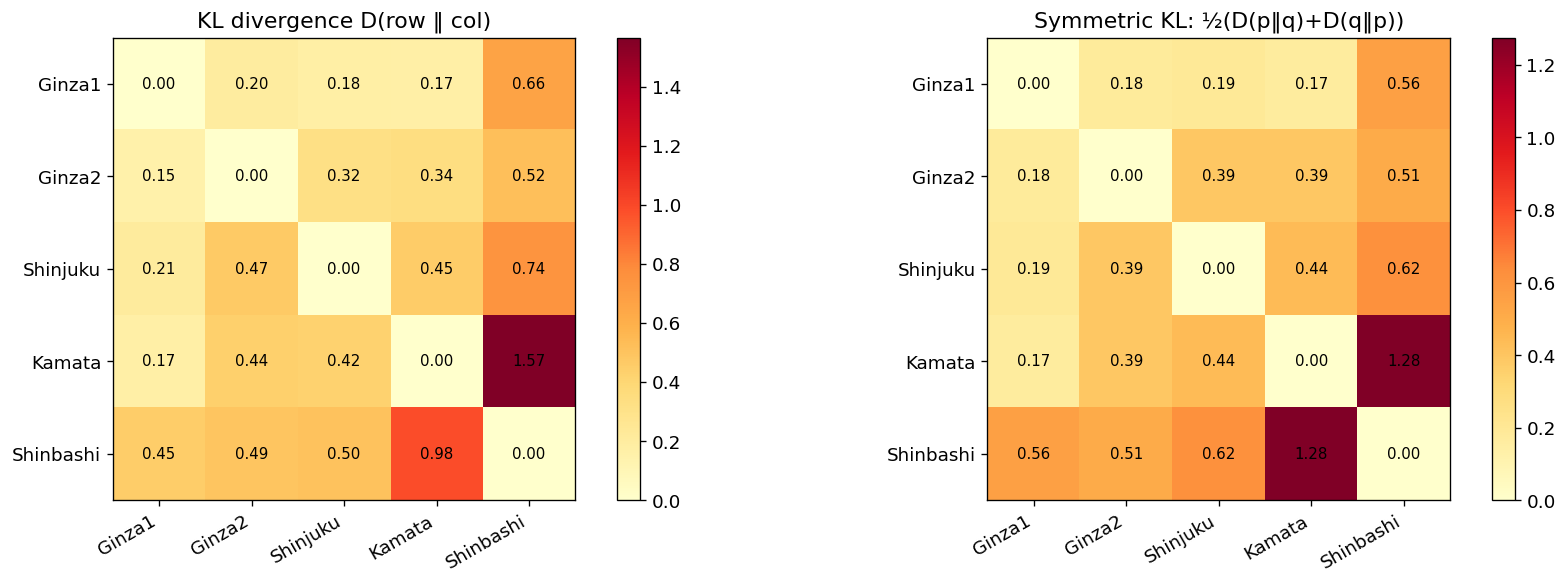

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Heatmap
ax = axes[0]
im = ax.imshow(kl_matrix, cmap='YlOrRd')
ax.set_xticks(range(n)); ax.set_xticklabels(keys, rotation=30, ha='right')
ax.set_yticks(range(n)); ax.set_yticklabels(keys)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{kl_matrix[i,j]:.2f}', ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax)
ax.set_title('KL divergence D(row ‖ col)')

# Symmetric distance (0.5 * (D(p||q) + D(q||p)))
ax2 = axes[1]
sym_kl = 0.5 * (kl_matrix + kl_matrix.T)
im2 = ax2.imshow(sym_kl, cmap='YlOrRd')
ax2.set_xticks(range(n)); ax2.set_xticklabels(keys, rotation=30, ha='right')
ax2.set_yticks(range(n)); ax2.set_yticklabels(keys)
for i in range(n):
    for j in range(n):
        ax2.text(j, i, f'{sym_kl[i,j]:.2f}', ha='center', va='center', fontsize=9)
plt.colorbar(im2, ax=ax2)
ax2.set_title('Symmetric KL: ½(D(p‖q)+D(q‖p))')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'kl_divergence_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Per-feature contribution to KL divergence

Which features drive the behavioral difference between stations?

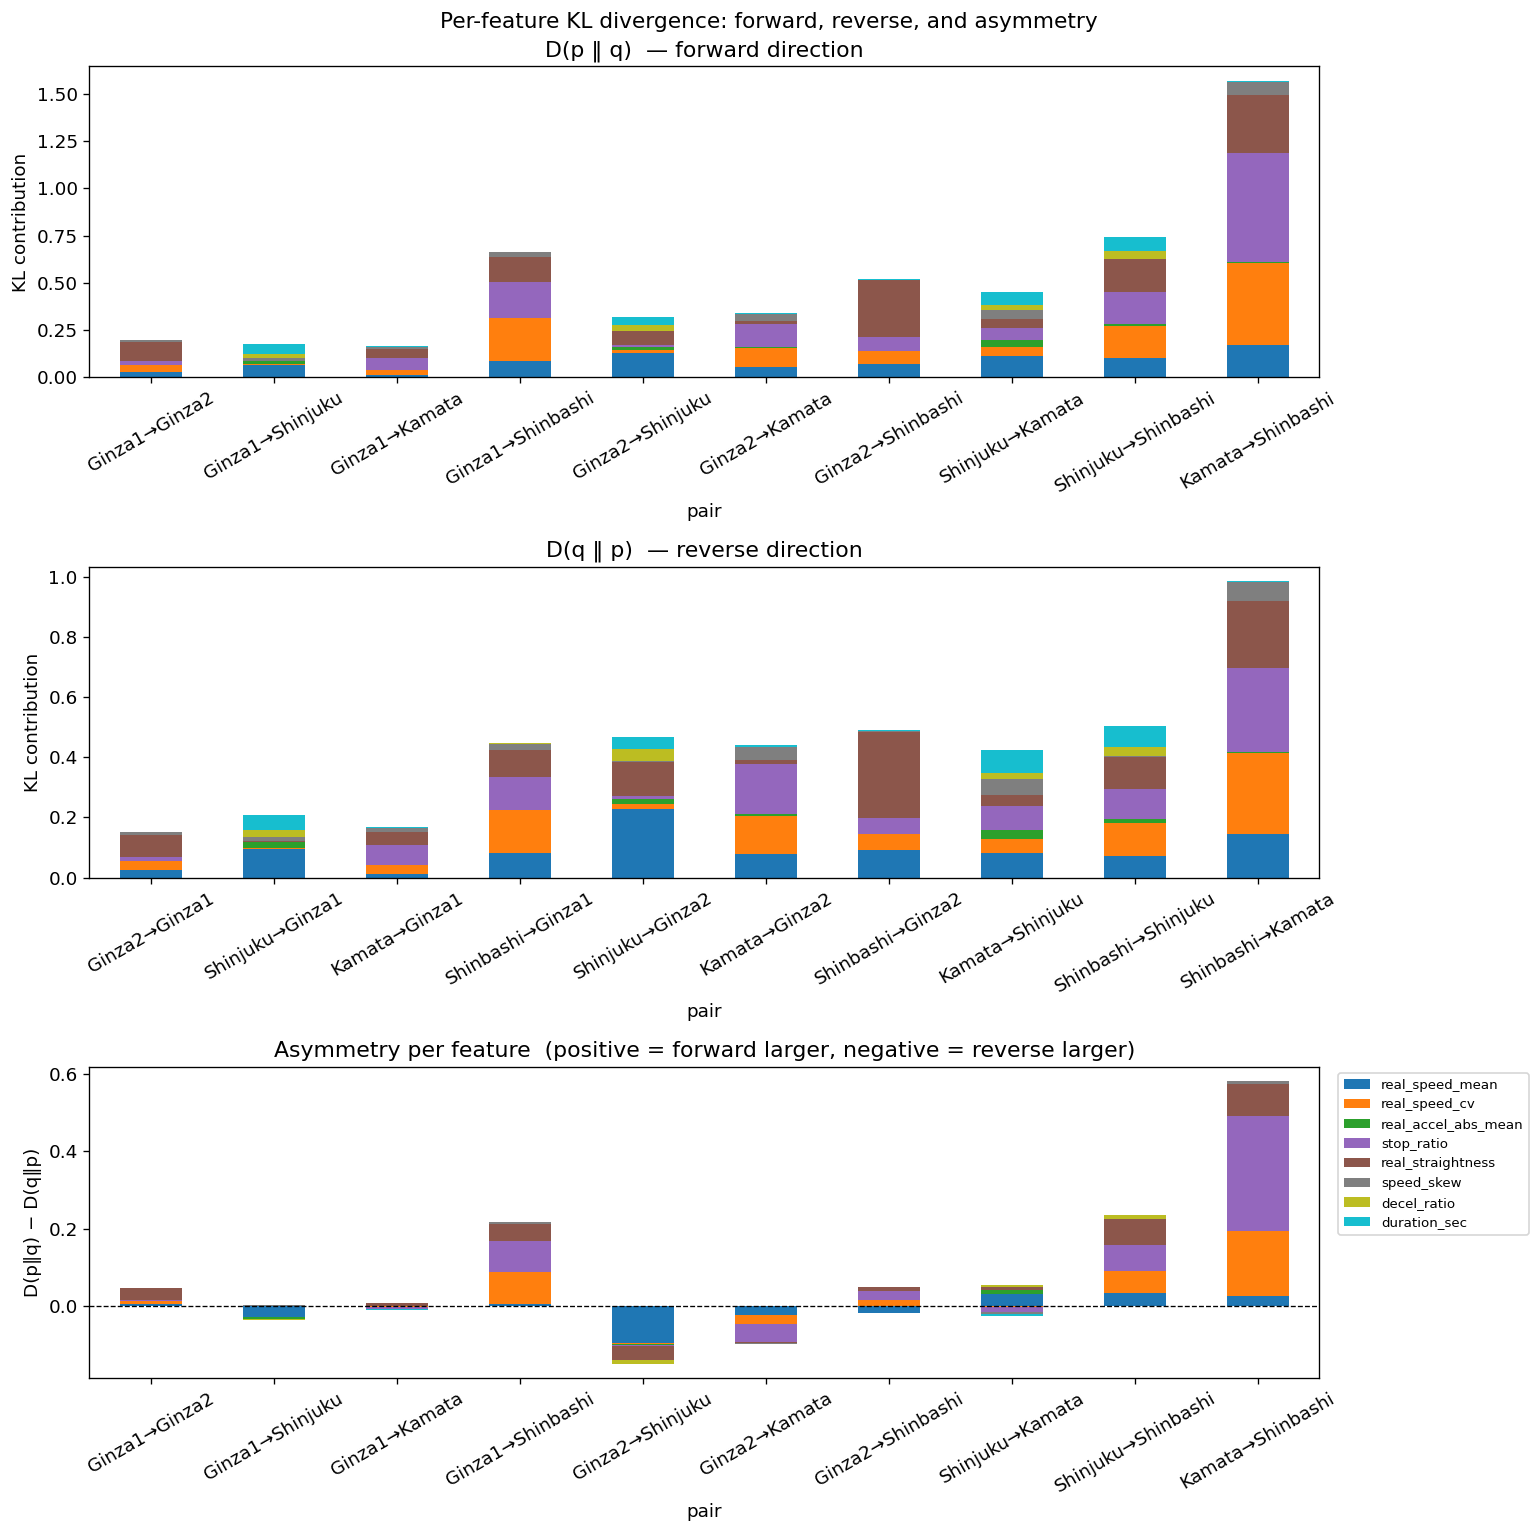

In [58]:
# Compute per-feature KL for all pairs (both directions)
pair_results_fwd = []
pair_results_rev = []
for i, ki in enumerate(keys):
    for j, kj in enumerate(keys):
        if i < j:
            total_fwd, per_feat_fwd = kl_stations(ki, kj)
            total_rev, per_feat_rev = kl_stations(kj, ki)
            row_fwd = {'pair': f'{ki}→{kj}', 'total': total_fwd}
            row_fwd.update(per_feat_fwd)
            pair_results_fwd.append(row_fwd)
            row_rev = {'pair': f'{kj}→{ki}', 'total': total_rev}
            row_rev.update(per_feat_rev)
            pair_results_rev.append(row_rev)

pair_df     = pd.DataFrame(pair_results_fwd).set_index('pair')
pair_df_rev = pd.DataFrame(pair_results_rev).set_index('pair')

# --- Figure: 3 rows ---
# Row 1: D(p||q)  forward
# Row 2: D(q||p)  reverse
# Row 3: asymmetry = D(p||q) - D(q||p) per feature

asym_df = pair_df[FEATURE_NAMES].copy()
for idx_f, idx_r in zip(pair_df.index, pair_df_rev.index):
    asym_df.loc[idx_f] = pair_df.loc[idx_f, FEATURE_NAMES].values - pair_df_rev.loc[idx_r, FEATURE_NAMES].values

fig, axes = plt.subplots(3, 1, figsize=(13, 13), sharex=False)

pair_df[FEATURE_NAMES].plot(
    kind='bar', stacked=True, ax=axes[0], colormap='tab10', legend=False)
axes[0].set_ylabel('KL contribution')
axes[0].set_title('D(p ‖ q)  — forward direction')
axes[0].tick_params(axis='x', rotation=30)

pair_df_rev[FEATURE_NAMES].plot(
    kind='bar', stacked=True, ax=axes[1], colormap='tab10', legend=False)
axes[1].set_ylabel('KL contribution')
axes[1].set_title('D(q ‖ p)  — reverse direction')
axes[1].tick_params(axis='x', rotation=30)

# Asymmetry: positive = forward > reverse, negative = reverse > forward
asym_df.plot(
    kind='bar', stacked=True, ax=axes[2], colormap='tab10')
axes[2].axhline(0, color='k', lw=0.8, linestyle='--')
axes[2].set_ylabel('D(p‖q) − D(q‖p)')
axes[2].set_title('Asymmetry per feature  (positive = forward larger, negative = reverse larger)')
axes[2].tick_params(axis='x', rotation=30)
axes[2].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.suptitle('Per-feature KL divergence: forward, reverse, and asymmetry', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'kl_per_feature_asymmetry.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. e/m geodesics between station pairs

**e-geodesic** (exponential geodesic): straight line in θ-space  
$$\theta(t) = (1-t)\,\theta_A + t\,\theta_B, \quad t \in [0,1]$$

**m-geodesic** (mixture geodesic): straight line in η-space  
$$\eta(t) = (1-t)\,\eta_A + t\,\eta_B, \quad t \in [0,1]$$

The asymmetry between the two paths reflects the **curvature** of M_U as seen from each dual connection.

In terms of the KL divergence, the e-geodesic midpoint minimizes  
$D(p \| m) + D(m \| q)$ (e-projection), while the m-geodesic midpoint minimizes  
$D(m \| p) + D(m \| q)$ (m-projection / mixture).

Most distant pair: kamata ↔ shinbashi  (sym-KL=1.275)


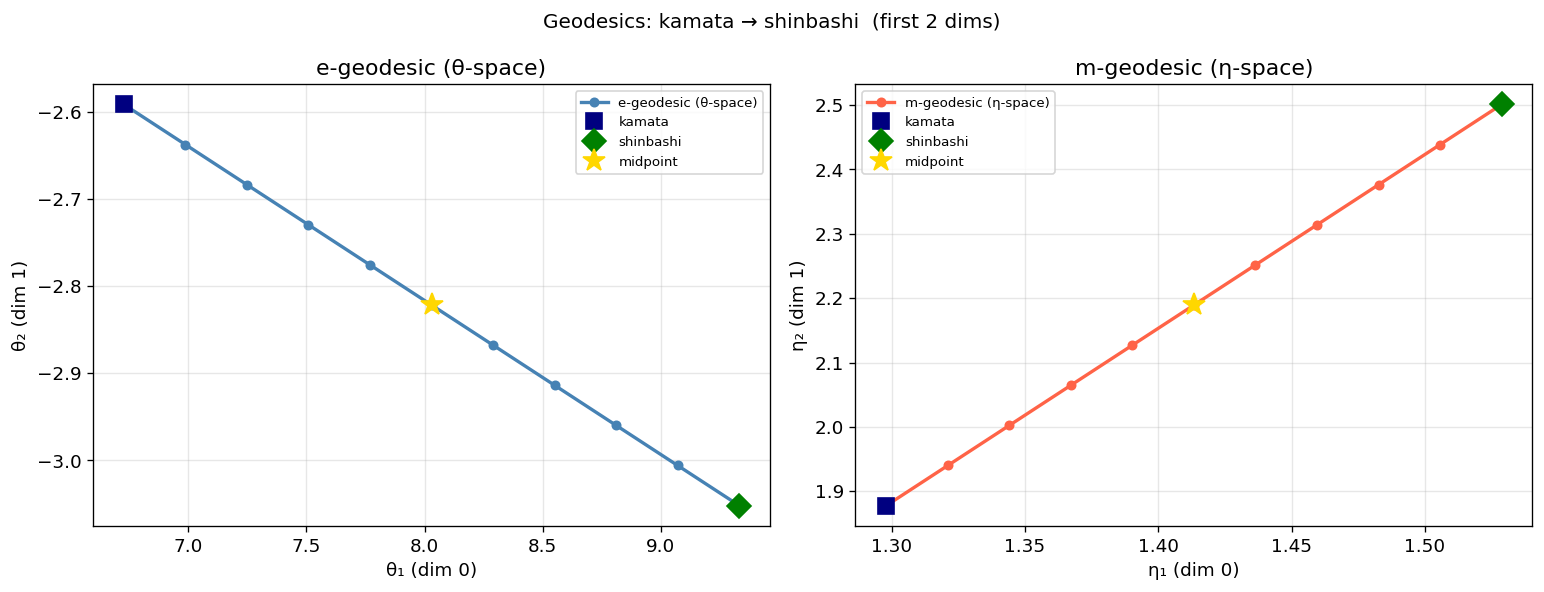

In [12]:
def geodesic_points(key_a, key_b, n_steps=11):
    """Return e-geodesic and m-geodesic as sequences of θ/η vectors."""
    theta_a, theta_b = station_theta[key_a], station_theta[key_b]
    eta_a,   eta_b   = station_eta[key_a],   station_eta[key_b]
    ts = np.linspace(0, 1, n_steps)
    e_geo = [(1-t)*theta_a + t*theta_b for t in ts]  # straight in θ
    m_geo = [(1-t)*eta_a   + t*eta_b   for t in ts]  # straight in η
    return ts, e_geo, m_geo


# Visualize geodesics for one pair: most distant stations
sym_kl_vals = [(sym_kl[i,j], keys[i], keys[j])
               for i in range(n) for j in range(i+1, n)]
sym_kl_vals.sort(reverse=True)
_, key_a, key_b = sym_kl_vals[0]
print(f"Most distant pair: {key_a} ↔ {key_b}  (sym-KL={sym_kl_vals[0][0]:.3f})")

ts, e_geo, m_geo = geodesic_points(key_a, key_b)

# Project to 2D for visualization: use first 2 θ dims (speed mean natural params)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (geo, label, color) in zip(axes, [
    (e_geo, 'e-geodesic (θ-space)', 'steelblue'),
    (m_geo, 'm-geodesic (η-space)', 'tomato')
]):
    pts = np.array(geo)
    ax.plot(pts[:, 0], pts[:, 1], '-o', color=color, lw=2, ms=5, label=label)
    ax.plot(pts[0, 0],  pts[0, 1],  's', color='navy', ms=10, label=key_a, zorder=5)
    ax.plot(pts[-1, 0], pts[-1, 1], 'D', color='green', ms=10, label=key_b, zorder=5)
    # Mark midpoint
    mid = pts[len(pts)//2]
    ax.plot(mid[0], mid[1], '*', color='gold', ms=14, zorder=6, label='midpoint')
    ax.set_xlabel('θ₁ (dim 0)' if 'e-' in label else 'η₁ (dim 0)')
    ax.set_ylabel('θ₂ (dim 1)' if 'e-' in label else 'η₂ (dim 1)')
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Geodesics: {key_a} → {key_b}  (first 2 dims)', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'geodesics_{key_a}_{key_b}.png', dpi=150, bbox_inches='tight')
plt.show()

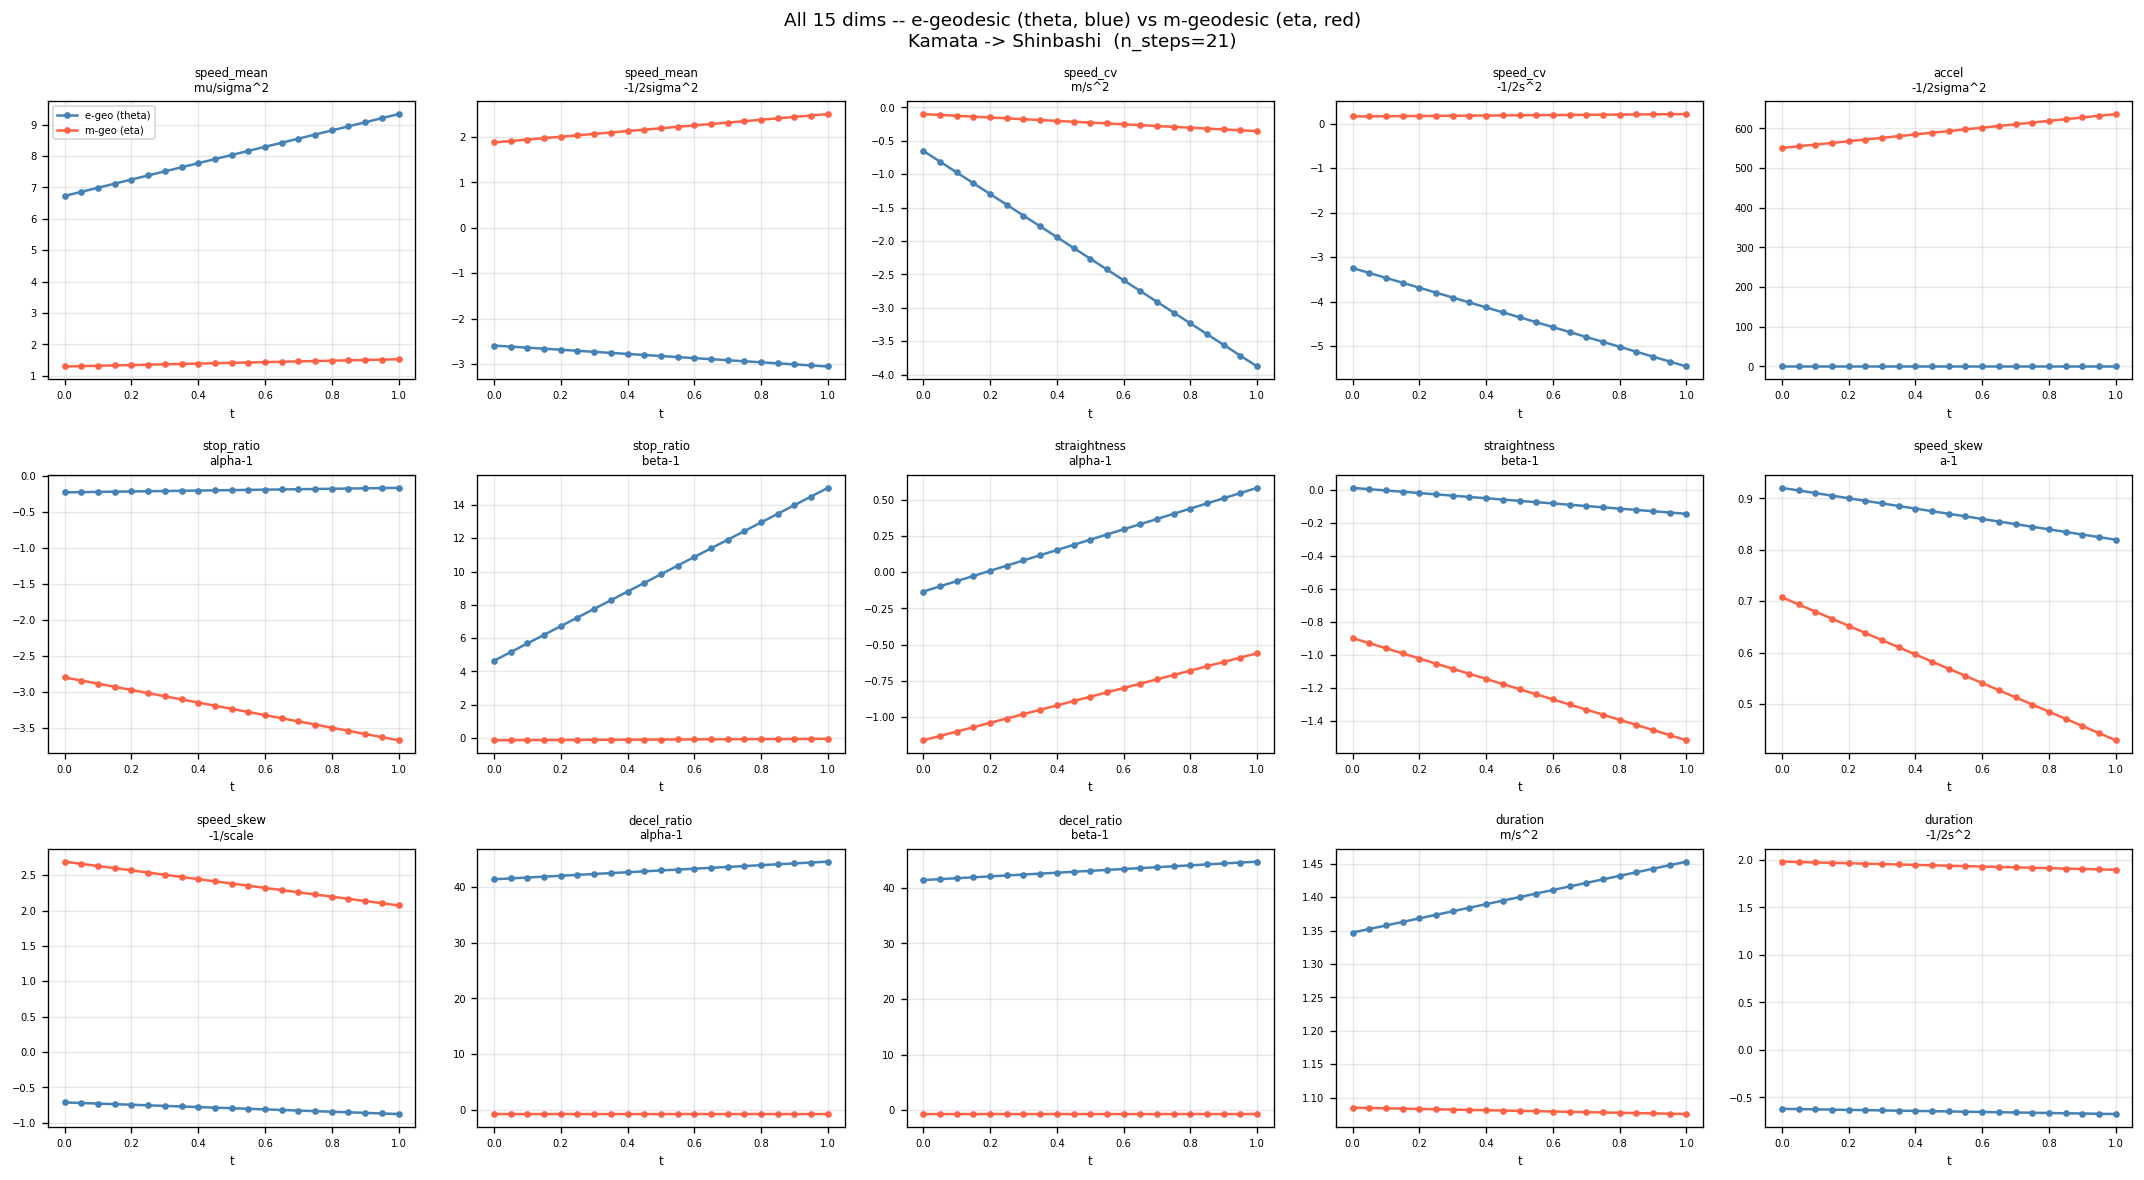

Note: e-geo values are theta_i, m-geo values are eta_i -- different coordinate systems, different scales per dim.


In [49]:
# === All 15 dimensions: e-geodesic (theta-space) and m-geodesic (eta-space) ===
# Each subplot shows one parameter dimension, x=t (0->1), y=parameter value

# Dimension labels matching the 15-dim vector layout:
# Normal(mu,sigma)       -> 2 dims : real_speed_mean
# Log-normal(s,scale)    -> 2 dims : real_speed_cv
# Half-normal(sigma)     -> 1 dim  : real_accel_abs_mean
# Beta(alpha,beta)       -> 2 dims : stop_ratio
# Beta(alpha,beta)       -> 2 dims : real_straightness
# Gamma(a,scale)         -> 2 dims : speed_skew
# Beta(alpha,beta)       -> 2 dims : decel_ratio
# Log-normal(s,scale)    -> 2 dims : duration_sec

theta_dim_labels = [
    "speed_mean\nmu/sigma^2",   "speed_mean\n-1/2sigma^2",
    "speed_cv\nm/s^2",           "speed_cv\n-1/2s^2",
    "accel\n-1/2sigma^2",
    "stop_ratio\nalpha-1",       "stop_ratio\nbeta-1",
    "straightness\nalpha-1",     "straightness\nbeta-1",
    "speed_skew\na-1",           "speed_skew\n-1/scale",
    "decel_ratio\nalpha-1",      "decel_ratio\nbeta-1",
    "duration\nm/s^2",           "duration\n-1/2s^2",
]

eta_dim_labels = [
    "speed_mean\nmu",             "speed_mean\nmu^2+sigma^2",
    "speed_cv\nm",                "speed_cv\nm^2+s^2",
    "accel\nsigma^2",
    "stop_ratio\npsi(a)-psi",     "stop_ratio\npsi(b)-psi",
    "straightness\npsi(a)-psi",   "straightness\npsi(b)-psi",
    "speed_skew\npsi(a)-log",     "speed_skew\na*scale",
    "decel_ratio\npsi(a)-psi",    "decel_ratio\npsi(b)-psi",
    "duration\nm",                "duration\nm^2+s^2",
]

n_dims = len(station_theta[key_a])  # 15
n_cols = 5
n_rows = (n_dims + n_cols - 1) // n_cols  # 3

ts_full, e_geo_full, m_geo_full = geodesic_points(key_a, key_b, n_steps=21)
e_pts = np.array(e_geo_full)   # shape (21, 15)
m_pts = np.array(m_geo_full)   # shape (21, 15)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10))
axes = axes.flatten()

for i in range(n_dims):
    ax = axes[i]
    ax.plot(ts_full, e_pts[:, i], "-o", color="steelblue", lw=1.5, ms=3, label="e-geo (theta)")
    ax.plot(ts_full, m_pts[:, i], "-o", color="tomato",    lw=1.5, ms=3, label="m-geo (eta)")
    ax.set_title(theta_dim_labels[i], fontsize=7)
    ax.set_xlabel("t", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=6)

for j in range(n_dims, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    f"All 15 dims -- e-geodesic (theta, blue) vs m-geodesic (eta, red)\n"
    f"{key_a} -> {key_b}  (n_steps=21)",
    fontsize=11
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"geodesics_all_dims_{key_a}_{key_b}.png", dpi=150, bbox_inches="tight")
plt.show()
print("Note: e-geo values are theta_i, m-geo values are eta_i -- different coordinate systems, different scales per dim.")


In [50]:
# === Inverse Legendre transform: eta -> theta ===
# Required to compare e-geodesic and m-geodesic in the same coordinate system.
# Each distribution family has its own analytical or numerical inversion.
from scipy.optimize import brentq, fsolve

# Number of eta/theta dims per distribution (must match to_expectation_params)
_DIST_DIMS = {'Normal': 2, 'Log-normal': 2, 'Half-normal': 1,
              'Beta': 2, 'Gamma': 2}

def _eta_seg_to_theta(dist_name, eta_seg):
    """Invert one distribution segment: eta -> theta."""
    if dist_name == 'Normal':
        eta0, eta1 = eta_seg
        sigma2 = eta1 - eta0**2
        return (eta0 / sigma2, -1.0 / (2.0 * sigma2))

    elif dist_name == 'Log-normal':
        eta0, eta1 = eta_seg        # eta0=m, eta1=m^2+s^2
        s2 = eta1 - eta0**2
        return (eta0 / s2, -1.0 / (2.0 * s2))

    elif dist_name == 'Half-normal':
        eta0, = eta_seg             # eta0 = sigma^2
        return (-1.0 / (2.0 * eta0),)

    elif dist_name == 'Gamma':
        eta0, eta1 = eta_seg        # eta0=psi(a)+log(scale), eta1=a*scale
        # scale = eta1/a  =>  eta0 = psi(a) + log(eta1/a)
        # f(a) = psi(a) - log(a) + log(eta1) - eta0 = 0
        target = eta0 - np.log(eta1)
        f = lambda a: digamma(float(a)) - np.log(float(a)) - target
        a_est = brentq(f, 1e-6, 1e4)
        scale_est = eta1 / a_est
        return (a_est - 1.0, -1.0 / scale_est)

    elif dist_name == 'Beta':
        eta0, eta1 = eta_seg        # eta0=psi(a)-psi(a+b), eta1=psi(b)-psi(a+b)
        def equations(log_ab):
            a, b = np.exp(log_ab)   # keep positive
            ab = a + b
            return [digamma(a) - digamma(ab) - eta0,
                    digamma(b) - digamma(ab) - eta1]
        sol = fsolve(equations, [0.0, 0.0], full_output=True)
        a_est, b_est = np.exp(sol[0])
        return (a_est - 1.0, b_est - 1.0)

    raise ValueError(f'Unknown distribution: {dist_name}')


def eta_vec_to_theta_vec(eta_vec):
    """Convert full 15-dim eta vector to theta vector using MANIFOLD_SCHEMA."""
    theta_out = []
    idx = 0
    for feat, dist_name, *_ in MANIFOLD_SCHEMA:
        d = _DIST_DIMS[dist_name]
        seg = eta_vec[idx: idx + d]
        theta_out.extend(_eta_seg_to_theta(dist_name, seg))
        idx += d
    return np.array(theta_out)


# Sanity check: eta -> theta should recover the original theta
for key in keys:
    recovered = eta_vec_to_theta_vec(station_eta[key])
    err = np.max(np.abs(recovered - station_theta[key]))
    print(f'{key:12s}  max reconstruction error: {err:.2e}')


def _theta_seg_to_scipy(dist_name, theta_seg):
    """Convert one theta segment to scipy-compatible params."""
    if dist_name == 'Normal':
        t0, t1 = theta_seg
        sigma2 = -1.0 / (2.0 * t1)
        mu = t0 * sigma2
        return (mu, np.sqrt(sigma2))

    elif dist_name == 'Log-normal':
        t0, t1 = theta_seg
        s2 = -1.0 / (2.0 * t1)
        m  = t0 * s2
        return (np.sqrt(s2), 0.0, np.exp(m))

    elif dist_name == 'Half-normal':
        t0, = theta_seg
        sigma2 = -1.0 / (2.0 * t0)
        return (0.0, np.sqrt(sigma2))

    elif dist_name == 'Gamma':
        t0, t1 = theta_seg
        a     = t0 + 1.0
        scale = -1.0 / t1
        return (a, 0.0, scale)

    elif dist_name == 'Beta':
        t0, t1 = theta_seg
        return (t0 + 1.0, t1 + 1.0, 0.0, 1.0)

    raise ValueError(f'Unknown distribution: {dist_name}')


def theta_vec_to_scipy_params(theta_vec):
    """Convert full 15-dim theta vector to dict of {feat: scipy_params}."""
    result = {}
    idx = 0
    for feat, dist_name, *_ in MANIFOLD_SCHEMA:
        d = _DIST_DIMS[dist_name]
        result[feat] = _theta_seg_to_scipy(dist_name, theta_vec[idx: idx + d])
        idx += d
    return result


# Sanity check: theta -> scipy -> kl with itself should be 0
key_test = keys[0]
params_self = theta_vec_to_scipy_params(station_theta[key_test])
self_kl = sum(kl_feature(f, params_self[f], params_self[f]) for f in params_self)
print(f'Self-KL ({key_test}): {self_kl:.2e}  (should be ~0)')


Ginza1        max reconstruction error: 1.17e-11
Ginza2        max reconstruction error: 9.77e-11
Shinjuku      max reconstruction error: 8.21e-11
Kamata        max reconstruction error: 1.52e-10
Shinbashi     max reconstruction error: 1.32e-10
Self-KL (Ginza1): 0.00e+00  (should be ~0)


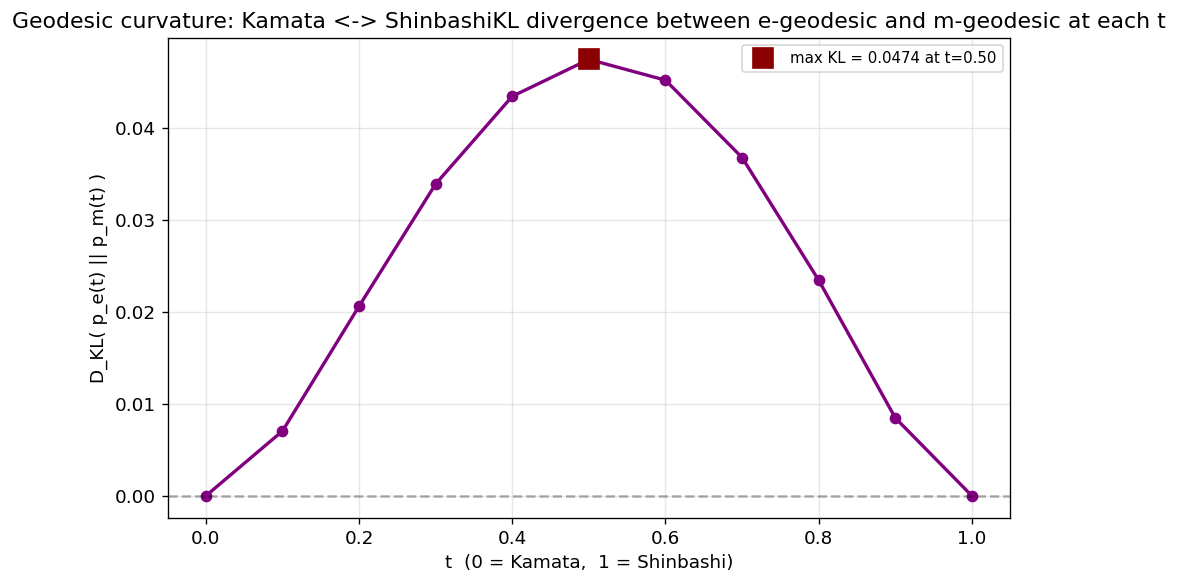

max KL gap: 0.047431 at t=0.50
mean KL gap (excl. endpoints): 0.029583
Note: KL=0 at t=0 and t=1 by construction (same station = same distribution)


In [65]:
# === Curvature analysis: KL divergence between e-geodesic and m-geodesic at each t ===
# e_geo(t): theta-space interpolation -> convert to scipy params
# m_geo(t): eta-space interpolation -> eta_to_theta -> convert to scipy params
# gap(t) = D_KL( p_e(t) || p_m(t) )  summed over all features

def kl_between_geodesic_points(theta_e, eta_m):
    """KL divergence between e-geodesic point (theta) and m-geodesic point (eta)."""
    theta_m = eta_vec_to_theta_vec(np.array(eta_m))
    params_e = theta_vec_to_scipy_params(np.array(theta_e))
    params_m = theta_vec_to_scipy_params(theta_m)
    return sum(kl_feature(f, params_e[f], params_m[f]) for f in params_e)


def divergence_analysis(key_a, key_b, n_steps=11):
    """Gap between e-geodesic and m-geodesic measured by KL divergence at each t."""
    ts, e_geo, m_geo = geodesic_points(key_a, key_b, n_steps)
    kl_gaps = [kl_between_geodesic_points(e_geo[i], m_geo[i])
               for i in range(len(ts))]
    return ts, kl_gaps, e_geo, m_geo


ts_div, kl_gaps, e_g, m_g = divergence_analysis(key_a, key_b)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ts_div, kl_gaps, 'o-', color='purple', lw=2, ms=6)
ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
max_idx = np.argmax(kl_gaps)
ax.plot(ts_div[max_idx], kl_gaps[max_idx], 's', color='darkred', ms=12,
        label=f'max KL = {kl_gaps[max_idx]:.4f} at t={ts_div[max_idx]:.2f}')
ax.set_xlabel('t  (0 = ' + key_a + ',  1 = ' + key_b + ')')
ax.set_ylabel('D_KL( p_e(t) || p_m(t) )')
ax.set_title(f'Geodesic curvature: {key_a} <-> {key_b}' 'KL divergence between e-geodesic and m-geodesic at each t')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'geodesic_kl_gap_{key_a}_{key_b}.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'max KL gap: {max(kl_gaps):.6f} at t={ts_div[max_idx]:.2f}')
print(f'mean KL gap (excl. endpoints): {np.mean(kl_gaps[1:-1]):.6f}')
print('Note: KL=0 at t=0 and t=1 by construction (same station = same distribution)')


最大曲率ペア: Kamata↔Shinbashi  max KL gap = 0.047431


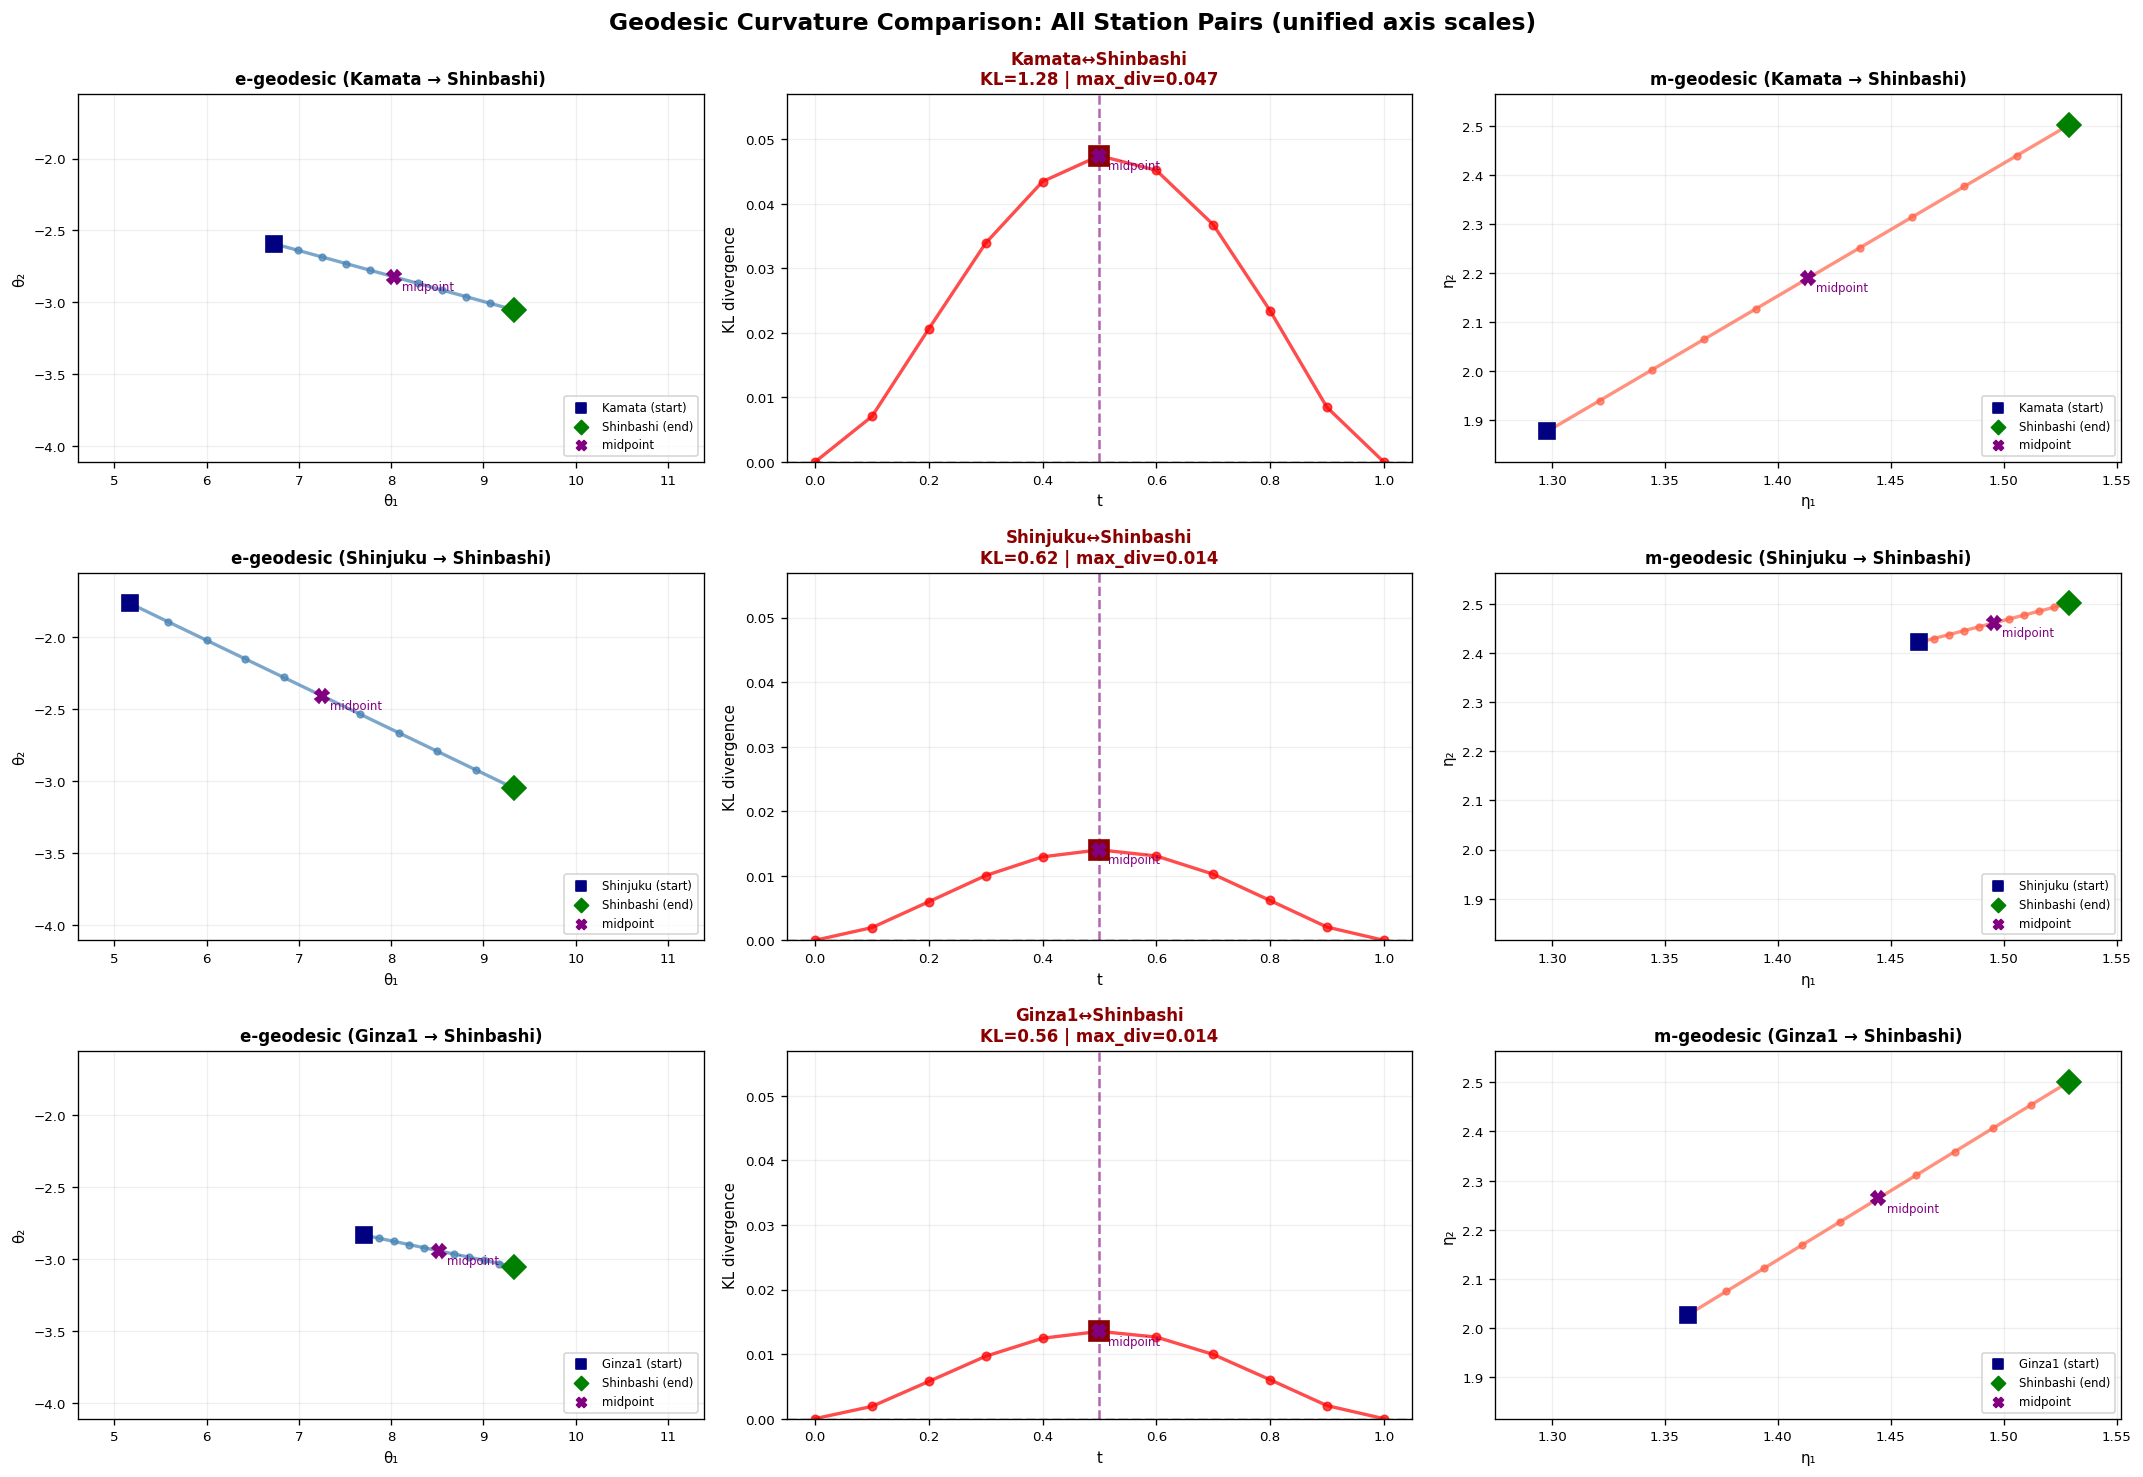

In [88]:
# === 2駅ペアの曲率比較（軸スケール統一） ===

# すべてのペアについて曲率を計算
pair_curvatures = []
for i in range(n):
    for j in range(i+1, n):
        ki, kj = keys[i], keys[j]
        ts_div, divs, e_geo, m_geo = divergence_analysis(ki, kj, n_steps=11)
        max_div = max(divs)
        mean_div = np.mean(divs)
        pair_curvatures.append({
            'pair': f'{ki}↔{kj}',
            'sym_kl': sym_kl[i, j],
            'max_divergence': max_div,
            'mean_divergence': mean_div,
            'e_geo': e_geo,
            'm_geo': m_geo,
            'ts': ts_div,
            'divs': divs
        })

# ソート: max_divergence で降順（最も曲率が大きい順）
pair_curvatures.sort(key=lambda x: x['max_divergence'], reverse=True)

max_pair_curvature = pair_curvatures[0]['max_divergence']
print(f"最大曲率ペア: {pair_curvatures[0]['pair']}  max KL gap = {max_pair_curvature:.6f}")

# すべてのe-geodesicおよびm-geodesicから共通スケールを計算
all_e_pts = np.vstack([np.array(p['e_geo']) for p in pair_curvatures])
all_m_pts = np.vstack([np.array(p['m_geo']) for p in pair_curvatures])

e_x_min, e_x_max = all_e_pts[:, 0].min(), all_e_pts[:, 0].max()
e_y_min, e_y_max = all_e_pts[:, 1].min(), all_e_pts[:, 1].max()
m_x_min, m_x_max = all_m_pts[:, 0].min(), all_m_pts[:, 0].max()
m_y_min, m_y_max = all_m_pts[:, 1].min(), all_m_pts[:, 1].max()

# スケール拡張（余白）
e_x_margin = (e_x_max - e_x_min) * 0.1
e_y_margin = (e_y_max - e_y_min) * 0.1
m_x_margin = (m_x_max - m_x_min) * 0.1
m_y_margin = (m_y_max - m_y_min) * 0.1

# 複数行の図を作成（ペアごとに1行）
n_pairs = len(pair_curvatures)
fig = plt.figure(figsize=(18, 4*n_pairs))
# row=0,3, 7のときのみ実施
for row, pdata in enumerate(pair_curvatures):
    if row >= 3:
        break

    pair_str = pdata['pair']
    ki, kj = pair_str.split('↔')

    # 左: e-geodesic（共通スケール）
    ax1 = plt.subplot(n_pairs, 3, row*3 + 1)
    pts_e = np.array(pdata['e_geo'])
    ax1.plot(pts_e[:, 0], pts_e[:, 1], '-o', color='steelblue', lw=2, ms=4, alpha=0.7)
    ax1.plot(pts_e[0, 0], pts_e[0, 1], 's', color='navy', ms=10, zorder=5)
    ax1.plot(pts_e[-1, 0], pts_e[-1, 1], 'D', color='green', ms=10, zorder=5)
    mid_idx = len(pts_e) // 2
    mid_e = pts_e[mid_idx]
    ax1.plot(mid_e[0], mid_e[1], 'X', color='purple', ms=8, zorder=6)
    ax1.annotate('midpoint', xy=(mid_e[0], mid_e[1]), xytext=(5, -8), textcoords='offset points', fontsize=7, color='purple')

    ax1.set_xlim(e_x_min - e_x_margin, e_x_max + e_x_margin)
    ax1.set_ylim(e_y_min - e_y_margin, e_y_max + e_y_margin)
    ax1.set_xlabel('θ₁', fontsize=9)
    ax1.set_ylabel('θ₂', fontsize=9)
    ax1.set_title(f'e-geodesic ({ki} → {kj})', fontsize=10, fontweight='bold')
    ax1.grid(True, alpha=0.2)
    ax1.tick_params(labelsize=8)

    ax1.scatter([], [], marker='s', color='navy', label=f'{ki} (start)')
    ax1.scatter([], [], marker='D', color='green', label=f'{kj} (end)')
    ax1.scatter([], [], marker='X', color='purple', label='midpoint')
    ax1.legend(fontsize=7, loc='lower right')

    # 中央: 乖離度
    ax2 = plt.subplot(n_pairs, 3, row*3 + 2)
    divs = pdata['divs']
    ts = pdata['ts']
    ax2.plot(ts, divs, 'o-', color='red', lw=2, ms=5, alpha=0.7)
    max_div_idx = np.argmax(divs)
    ax2.plot(ts[max_div_idx], divs[max_div_idx], 's', color='darkred', ms=12, zorder=5)

    mid_div = divs[mid_idx]
    ax2.plot(0.5, mid_div, 'X', color='purple', ms=8, zorder=6)
    ax2.set_ylim(0, max_pair_curvature * 1.2)
    ax2.annotate('midpoint', xy=(0.5, mid_div), xytext=(5, -8), textcoords='offset points', fontsize=7, color='purple')
    ax2.axvline(x=0.5, color='purple', linestyle='--', alpha=0.6)
    ax2.axhline(y=0, color='k', linestyle='--', alpha=0.2)

    ax2.set_xlabel('t', fontsize=9)
    ax2.set_ylabel('KL divergence', fontsize=9)
    ax2.set_title(f'{pair_str}\nKL={pdata["sym_kl"]:.2f} | max_div={pdata["max_divergence"]:.3f}', 
                  fontsize=10, fontweight='bold', color='darkred')
    ax2.grid(True, alpha=0.2)
    ax2.tick_params(labelsize=8)

    # 右: m-geodesic（共通スケール）
    ax3 = plt.subplot(n_pairs, 3, row*3 + 3)
    pts_m = np.array(pdata['m_geo'])
    ax3.plot(pts_m[:, 0], pts_m[:, 1], '-o', color='tomato', lw=2, ms=4, alpha=0.7)
    ax3.plot(pts_m[0, 0], pts_m[0, 1], 's', color='navy', ms=10, zorder=5)
    ax3.plot(pts_m[-1, 0], pts_m[-1, 1], 'D', color='green', ms=10, zorder=5)
    mid_m = pts_m[mid_idx]
    ax3.plot(mid_m[0], mid_m[1], 'X', color='purple', ms=8, zorder=6)
    ax3.annotate('midpoint', xy=(mid_m[0], mid_m[1]), xytext=(5, -8), textcoords='offset points', fontsize=7, color='purple')

    ax3.set_xlim(m_x_min - m_x_margin, m_x_max + m_x_margin)
    ax3.set_ylim(m_y_min - m_y_margin, m_y_max + m_y_margin)
    ax3.set_xlabel('η₁', fontsize=9)
    ax3.set_ylabel('η₂', fontsize=9)
    ax3.set_title(f'm-geodesic ({ki} → {kj})', fontsize=10, fontweight='bold')
    ax3.grid(True, alpha=0.2)
    ax3.tick_params(labelsize=8)

    ax3.scatter([], [], marker='s', color='navy', label=f'{ki} (start)')
    ax3.scatter([], [], marker='D', color='green', label=f'{kj} (end)')
    ax3.scatter([], [], marker='X', color='purple', label='midpoint')
    ax3.legend(fontsize=7, loc='lower right')

plt.suptitle('Geodesic Curvature Comparison: All Station Pairs (unified axis scales)', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'geodesics_all_pairs_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

最大曲率ペア: Kamata↔Shinbashi  max KL gap = 0.047431


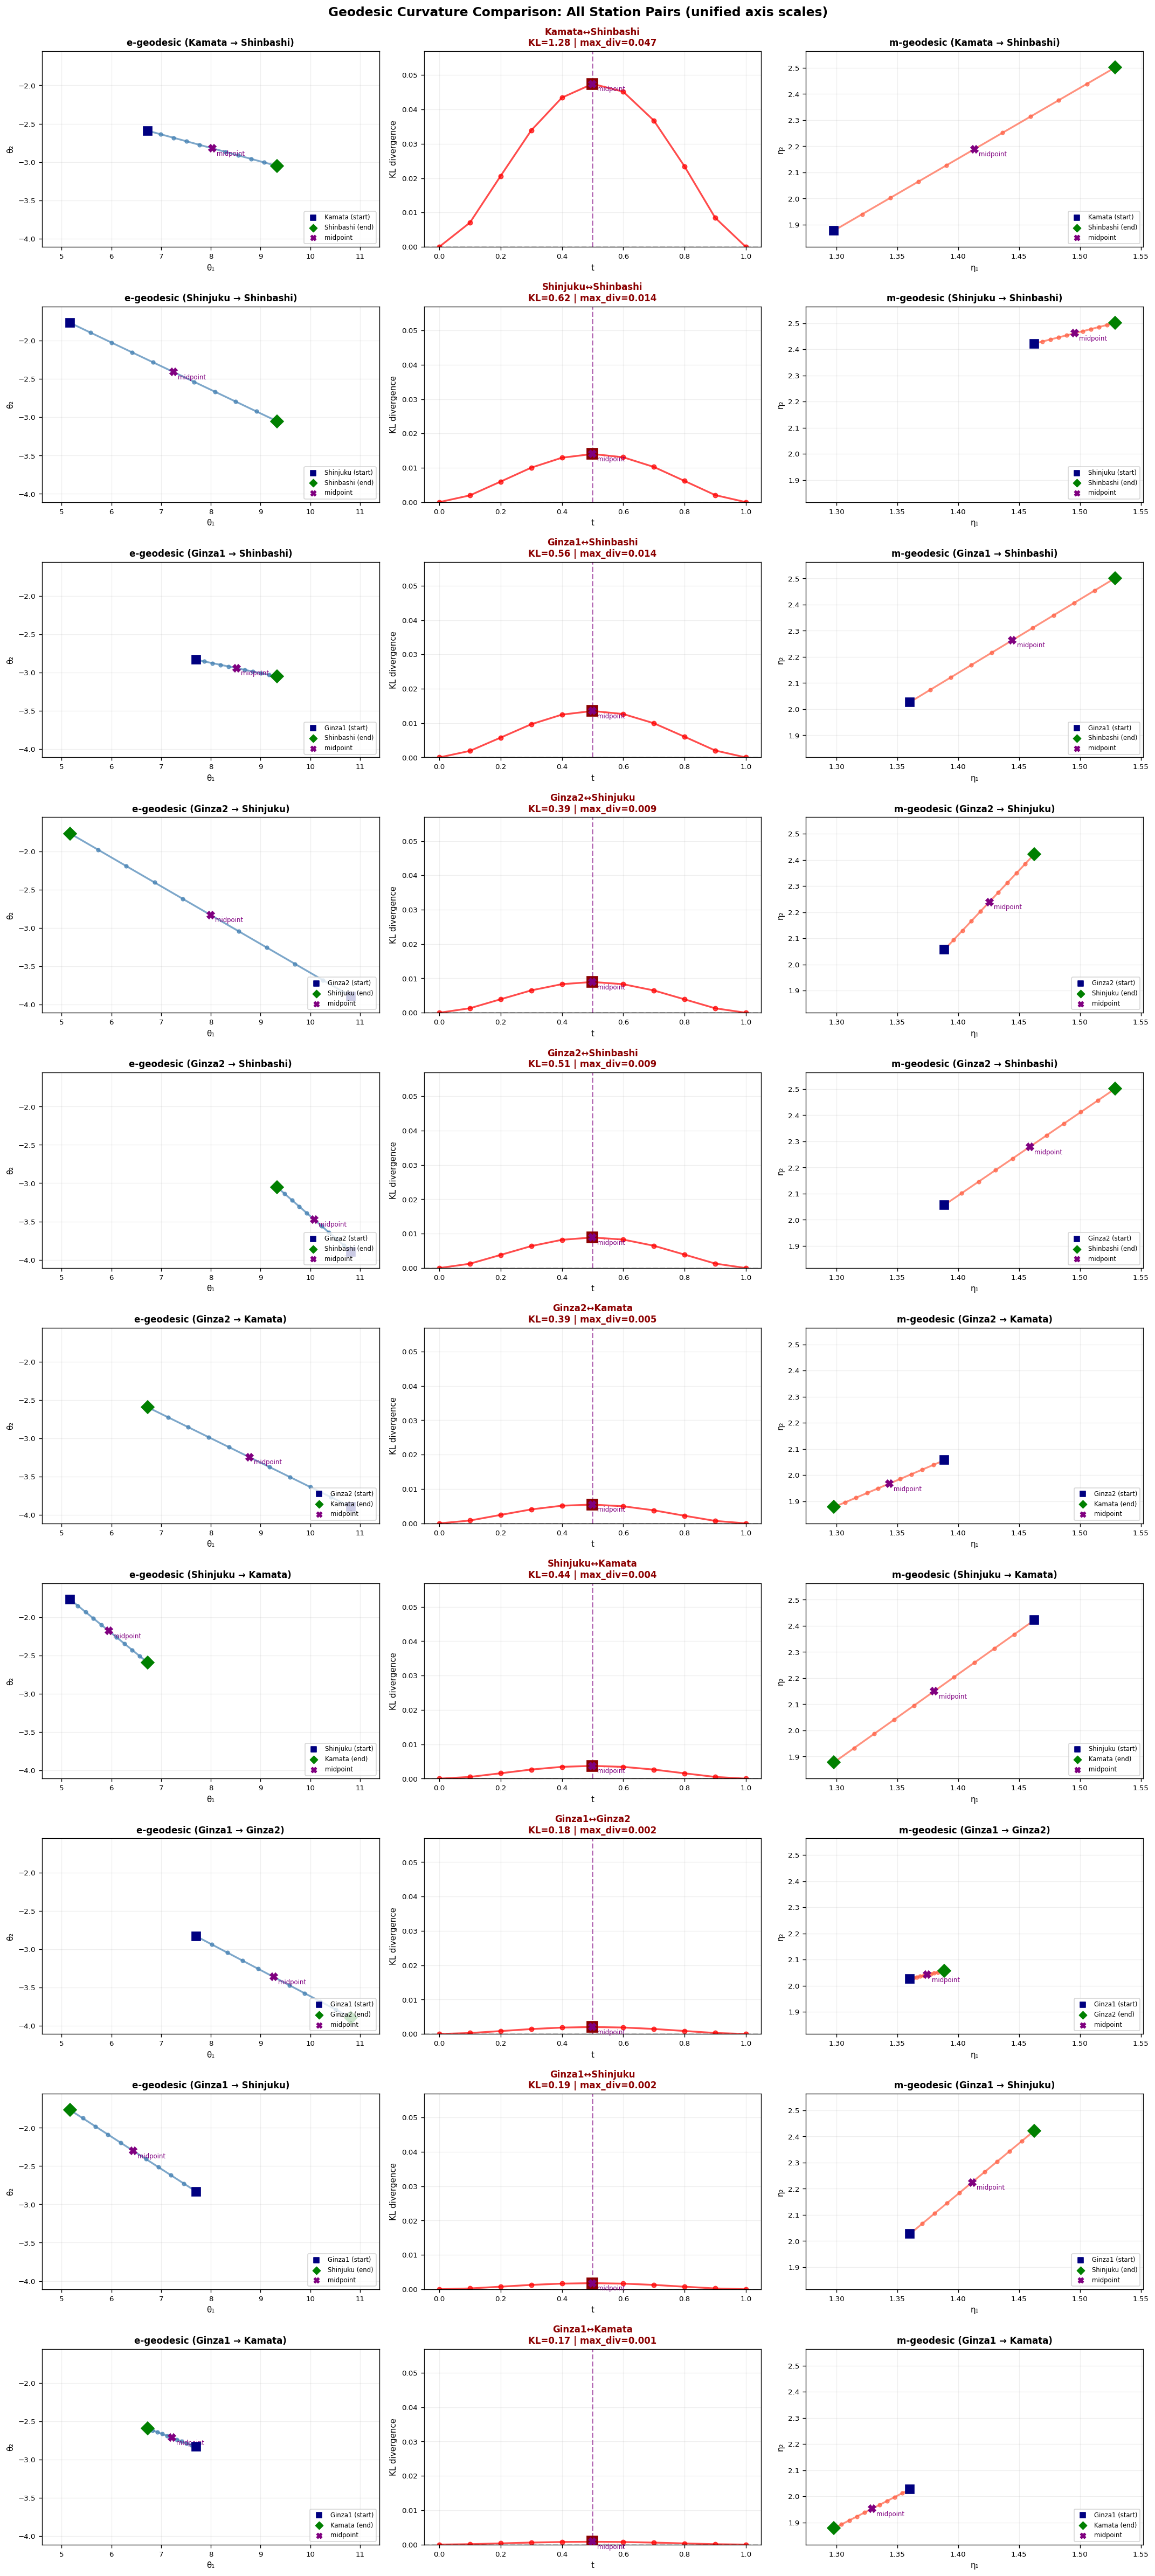


=== Curvature Summary: All Pairs (sorted by max divergence) ===

              Pair  Sym-KL Max Div Mean Div Nonlinearity
  Kamata↔Shinbashi 1.27542 0.04743  0.02420         High
Shinjuku↔Shinbashi 0.62270 0.01401  0.00695       Medium
  Ginza1↔Shinbashi 0.55669 0.01352  0.00672       Medium
   Ginza2↔Shinjuku 0.39324 0.00896  0.00446       Medium
  Ginza2↔Shinbashi 0.50506 0.00890  0.00442       Medium
     Ginza2↔Kamata 0.39019 0.00546  0.00269          Low
   Shinjuku↔Kamata 0.43869 0.00372  0.00182          Low
     Ginza1↔Ginza2 0.17615 0.00202  0.00099          Low
   Ginza1↔Shinjuku 0.19169 0.00178  0.00087          Low
     Ginza1↔Kamata 0.16602 0.00081  0.00040          Low

📊 Axis Scale Note:
  - e-geodesic (left column):  θ₁ ∈ [5.17, 10.82],  θ₂ ∈ [-3.90, -1.77]
  - m-geodesic (right column): η₁ ∈ [1.30, 1.53],  η₂ ∈ [1.88, 2.50]
  - Unified scales allow direct visual comparison across all station pairs

=== θ/η の意味 ===
θ は自然パラメータ座標（exponential family の natural parameter）、例

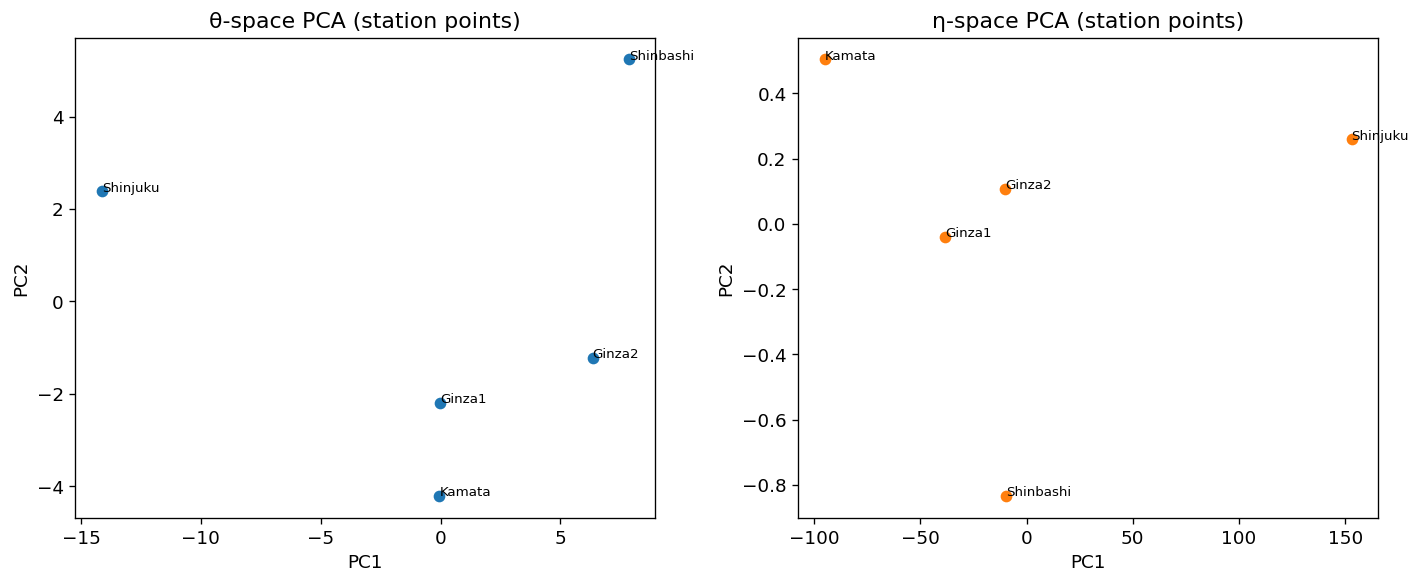

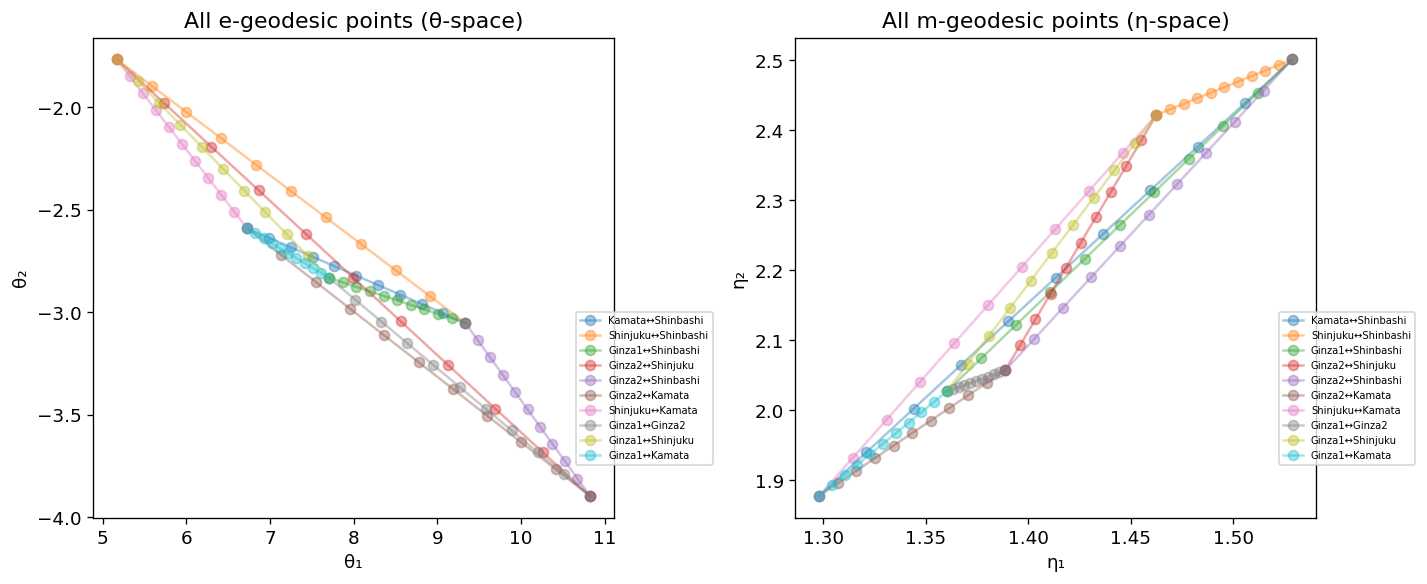

In [66]:

# === 全駅ペアの曲率比較（軸スケール統一） ===

# すべてのペアについて曲率を計算
pair_curvatures = []
for i in range(n):
    for j in range(i+1, n):
        ki, kj = keys[i], keys[j]
        ts_div, divs, e_geo, m_geo = divergence_analysis(ki, kj, n_steps=11)
        max_div = max(divs)
        mean_div = np.mean(divs)
        pair_curvatures.append({
            'pair': f'{ki}↔{kj}',
            'sym_kl': sym_kl[i, j],
            'max_divergence': max_div,
            'mean_divergence': mean_div,
            'e_geo': e_geo,
            'm_geo': m_geo,
            'ts': ts_div,
            'divs': divs
        })

# ソート: max_divergence で降順（最も曲率が大きい順）
pair_curvatures.sort(key=lambda x: x['max_divergence'], reverse=True)

max_pair_curvature = pair_curvatures[0]['max_divergence']
print(f"最大曲率ペア: {pair_curvatures[0]['pair']}  max KL gap = {max_pair_curvature:.6f}")

# すべてのe-geodesicおよびm-geodesicから共通スケールを計算
all_e_pts = np.vstack([np.array(p['e_geo']) for p in pair_curvatures])
all_m_pts = np.vstack([np.array(p['m_geo']) for p in pair_curvatures])

e_x_min, e_x_max = all_e_pts[:, 0].min(), all_e_pts[:, 0].max()
e_y_min, e_y_max = all_e_pts[:, 1].min(), all_e_pts[:, 1].max()
m_x_min, m_x_max = all_m_pts[:, 0].min(), all_m_pts[:, 0].max()
m_y_min, m_y_max = all_m_pts[:, 1].min(), all_m_pts[:, 1].max()

# スケール拡張（余白）
e_x_margin = (e_x_max - e_x_min) * 0.1
e_y_margin = (e_y_max - e_y_min) * 0.1
m_x_margin = (m_x_max - m_x_min) * 0.1
m_y_margin = (m_y_max - m_y_min) * 0.1

# 複数行の図を作成（ペアごとに1行）
n_pairs = len(pair_curvatures)
fig = plt.figure(figsize=(18, 4*n_pairs))

for row, pdata in enumerate(pair_curvatures):
    pair_str = pdata['pair']
    ki, kj = pair_str.split('↔')

    # 左: e-geodesic（共通スケール）
    ax1 = plt.subplot(n_pairs, 3, row*3 + 1)
    pts_e = np.array(pdata['e_geo'])
    ax1.plot(pts_e[:, 0], pts_e[:, 1], '-o', color='steelblue', lw=2, ms=4, alpha=0.7)
    ax1.plot(pts_e[0, 0], pts_e[0, 1], 's', color='navy', ms=10, zorder=5)
    ax1.plot(pts_e[-1, 0], pts_e[-1, 1], 'D', color='green', ms=10, zorder=5)
    mid_idx = len(pts_e) // 2
    mid_e = pts_e[mid_idx]
    ax1.plot(mid_e[0], mid_e[1], 'X', color='purple', ms=8, zorder=6)
    ax1.annotate('midpoint', xy=(mid_e[0], mid_e[1]), xytext=(5, -8), textcoords='offset points', fontsize=7, color='purple')

    ax1.set_xlim(e_x_min - e_x_margin, e_x_max + e_x_margin)
    ax1.set_ylim(e_y_min - e_y_margin, e_y_max + e_y_margin)
    ax1.set_xlabel('θ₁', fontsize=9)
    ax1.set_ylabel('θ₂', fontsize=9)
    ax1.set_title(f'e-geodesic ({ki} → {kj})', fontsize=10, fontweight='bold')
    ax1.grid(True, alpha=0.2)
    ax1.tick_params(labelsize=8)

    ax1.scatter([], [], marker='s', color='navy', label=f'{ki} (start)')
    ax1.scatter([], [], marker='D', color='green', label=f'{kj} (end)')
    ax1.scatter([], [], marker='X', color='purple', label='midpoint')
    ax1.legend(fontsize=7, loc='lower right')

    # 中央: 乖離度
    ax2 = plt.subplot(n_pairs, 3, row*3 + 2)
    divs = pdata['divs']
    ts = pdata['ts']
    ax2.plot(ts, divs, 'o-', color='red', lw=2, ms=5, alpha=0.7)
    max_div_idx = np.argmax(divs)
    ax2.plot(ts[max_div_idx], divs[max_div_idx], 's', color='darkred', ms=12, zorder=5)

    mid_div = divs[mid_idx]
    ax2.plot(0.5, mid_div, 'X', color='purple', ms=8, zorder=6)
    ax2.set_ylim(0, max_pair_curvature * 1.2)
    ax2.annotate('midpoint', xy=(0.5, mid_div), xytext=(5, -8), textcoords='offset points', fontsize=7, color='purple')
    ax2.axvline(x=0.5, color='purple', linestyle='--', alpha=0.6)
    ax2.axhline(y=0, color='k', linestyle='--', alpha=0.2)

    ax2.set_xlabel('t', fontsize=9)
    ax2.set_ylabel('KL divergence', fontsize=9)
    ax2.set_title(f'{pair_str}\nKL={pdata["sym_kl"]:.2f} | max_div={pdata["max_divergence"]:.3f}', 
                  fontsize=10, fontweight='bold', color='darkred')
    ax2.grid(True, alpha=0.2)
    ax2.tick_params(labelsize=8)

    # 右: m-geodesic（共通スケール）
    ax3 = plt.subplot(n_pairs, 3, row*3 + 3)
    pts_m = np.array(pdata['m_geo'])
    ax3.plot(pts_m[:, 0], pts_m[:, 1], '-o', color='tomato', lw=2, ms=4, alpha=0.7)
    ax3.plot(pts_m[0, 0], pts_m[0, 1], 's', color='navy', ms=10, zorder=5)
    ax3.plot(pts_m[-1, 0], pts_m[-1, 1], 'D', color='green', ms=10, zorder=5)
    mid_m = pts_m[mid_idx]
    ax3.plot(mid_m[0], mid_m[1], 'X', color='purple', ms=8, zorder=6)
    ax3.annotate('midpoint', xy=(mid_m[0], mid_m[1]), xytext=(5, -8), textcoords='offset points', fontsize=7, color='purple')

    ax3.set_xlim(m_x_min - m_x_margin, m_x_max + m_x_margin)
    ax3.set_ylim(m_y_min - m_y_margin, m_y_max + m_y_margin)
    ax3.set_xlabel('η₁', fontsize=9)
    ax3.set_ylabel('η₂', fontsize=9)
    ax3.set_title(f'm-geodesic ({ki} → {kj})', fontsize=10, fontweight='bold')
    ax3.grid(True, alpha=0.2)
    ax3.tick_params(labelsize=8)

    ax3.scatter([], [], marker='s', color='navy', label=f'{ki} (start)')
    ax3.scatter([], [], marker='D', color='green', label=f'{kj} (end)')
    ax3.scatter([], [], marker='X', color='purple', label='midpoint')
    ax3.legend(fontsize=7, loc='lower right')

plt.suptitle('Geodesic Curvature Comparison: All Station Pairs (unified axis scales)', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'geodesics_all_pairs_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# サマリーテーブル
print("\n=== Curvature Summary: All Pairs (sorted by max divergence) ===\n")
summary_df = pd.DataFrame([
    {
        'Pair': p['pair'],
        'Sym-KL': f"{p['sym_kl']:.5f}",
        'Max Div': f"{p['max_divergence']:.5f}",
        'Mean Div': f"{p['mean_divergence']:.5f}",
        'Nonlinearity': 'High' if p['max_divergence'] > 0.04 else 'Medium' if p['max_divergence'] > 0.008 else 'Low'
    }
    for p in pair_curvatures
])
print(summary_df.to_string(index=False))

print("\n📊 Axis Scale Note:")
print(f"  - e-geodesic (left column):  θ₁ ∈ [{e_x_min:.2f}, {e_x_max:.2f}],  θ₂ ∈ [{e_y_min:.2f}, {e_y_max:.2f}]")
print(f"  - m-geodesic (right column): η₁ ∈ [{m_x_min:.2f}, {m_x_max:.2f}],  η₂ ∈ [{m_y_min:.2f}, {m_y_max:.2f}]")
print("  - Unified scales allow direct visual comparison across all station pairs")

# --- 追加: θ/η の意味と PCA 解析比較 ---
print("\n=== θ/η の意味 ===")
print("θ は自然パラメータ座標（exponential family の natural parameter）、例: X~Normal(μ,σ) なら自然パラメータ θ=(μ/σ², -1/(2σ²)) 相当")
print("η は期待値パラメータ（期待値空間）。同じ例で η=(μ, μ²+σ²) 相当")

# Station θ/η の行列を PCA して、単純 PCA なら他にどんな構造が見えるか
theta_mat = np.vstack([station_theta[k] for k in keys])
eta_mat = np.vstack([station_eta[k] for k in keys])

pca_theta = PCA(n_components=2).fit(theta_mat)
pca_eta = PCA(n_components=2).fit(eta_mat)

theta_proj = pca_theta.transform(theta_mat)
eta_proj = pca_eta.transform(eta_mat)

print("\n=== PCA 比較 ===")
print(f"theta PCA explained {pca_theta.explained_variance_ratio_.sum():.3f}, components: {pca_theta.explained_variance_ratio_}")
print(f"eta PCA explained {pca_eta.explained_variance_ratio_.sum():.3f}, components: {pca_eta.explained_variance_ratio_}")

fig_pca, axes_pca = plt.subplots(1, 2, figsize=(12, 5))
axes_pca[0].scatter(theta_proj[:, 0], theta_proj[:, 1], c='tab:blue')
for i,k in enumerate(keys):
    axes_pca[0].text(theta_proj[i,0], theta_proj[i,1], k, fontsize=8)
axes_pca[0].set_title('θ-space PCA (station points)')
axes_pca[0].set_xlabel('PC1')
axes_pca[0].set_ylabel('PC2')

axes_pca[1].scatter(eta_proj[:, 0], eta_proj[:, 1], c='tab:orange')
for i,k in enumerate(keys):
    axes_pca[1].text(eta_proj[i,0], eta_proj[i,1], k, fontsize=8)
axes_pca[1].set_title('η-space PCA (station points)')
axes_pca[1].set_xlabel('PC1')
axes_pca[1].set_ylabel('PC2')
fig_pca.tight_layout()
plt.show()

# --- 追加: e/m 経路全点オーバーレイ ---
fig_all, (ax_all_e, ax_all_m) = plt.subplots(1, 2, figsize=(12, 5))
for pdata in pair_curvatures:
    pts_e = np.array(pdata['e_geo'])
    pts_m = np.array(pdata['m_geo'])
    ax_all_e.plot(pts_e[:,0], pts_e[:,1], '-o', alpha=0.4, label=pdata['pair'])
    ax_all_m.plot(pts_m[:,0], pts_m[:,1], '-o', alpha=0.4, label=pdata['pair'])

ax_all_e.set_title('All e-geodesic points (θ-space)')
ax_all_e.set_xlabel('θ₁')
ax_all_e.set_ylabel('θ₂')
ax_all_e.legend(fontsize=6, loc='lower right', bbox_to_anchor=(1.2, 0.1))

ax_all_m.set_title('All m-geodesic points (η-space)')
ax_all_m.set_xlabel('η₁')
ax_all_m.set_ylabel('η₂')
ax_all_m.legend(fontsize=6, loc='lower right', bbox_to_anchor=(1.2, 0.1))

fig_all.tight_layout()
plt.show()


## 11. Pythagorean decomposition

For any three points p, q, r on a dually flat manifold, the generalized Pythagorean theorem states:
$$D(p \| r) = D(p \| q) + D(q \| r) + \langle \theta_q - \theta_r,\, \eta_p - \eta_q \rangle$$

The inner product term vanishes when the e-geodesic from q to r is **m-orthogonal** to the m-geodesic from p to q.

This will be the key tool in Series 2: decomposing the perturbation effect (Interface Layer) into  
the component **explained by M_C** (e-projection onto the spatial manifold subspace) and the  
**residual** not explained by urban structure.

In [70]:
keys

['Ginza1', 'Ginza2', 'Shinjuku', 'Kamata', 'Shinbashi']

In [78]:
def pythagorean_check(key_p, key_q, key_r):
    """Check generalized Pythagorean theorem for three stations."""
    d_pr, _  = kl_stations(key_p, key_r)
    d_pq, _  = kl_stations(key_p, key_q)
    d_qr, _  = kl_stations(key_q, key_r)
    theta_q, theta_r = station_theta[key_q], station_theta[key_r]
    eta_p,   eta_q   = station_eta[key_p],   station_eta[key_q]
    inner = np.dot(theta_q - theta_r, eta_p - eta_q)
    lhs = d_pr
    rhs = d_pq + d_qr + inner
    return {
        'D(p‖r)': round(lhs, 4),
        'D(p‖q)+D(q‖r)+⟨Δθ,Δη⟩': round(rhs, 4),
        'residual': round(lhs - rhs, 6),
        'inner_product': round(inner, 4),
    }


# Check for all ordered triplets
from itertools import permutations
print(f"{'p':10} {'q':10} {'r':10} | D(p‖r)   D(p‖q)+D(q‖r)+⟨Δθ,Δη⟩   inner   residual")
for p, q, r in permutations(keys[1:4], 3):
    res = pythagorean_check(p, q, r)
    print(f"{p:10} {q:10} {r:10} | {res['D(p‖r)']:8.4f}  {res['D(p‖q)+D(q‖r)+⟨Δθ,Δη⟩']:8.4f}              {res['inner_product']:7.4f}   {res['residual']:.4e}")

p          q          r          | D(p‖r)   D(p‖q)+D(q‖r)+⟨⟩   inner   residual
Ginza2     Shinjuku   Kamata     |   0.3411    0.3411              -0.4315   -0.0000e+00
Ginza2     Kamata     Shinjuku   |   0.3193    0.3193              -0.4459   -0.0000e+00
Shinjuku   Ginza2     Kamata     |   0.4533    0.4533              -0.3550   0.0000e+00
Shinjuku   Kamata     Ginza2     |   0.4672    0.4672              -0.4253   -0.0000e+00
Kamata     Ginza2     Shinjuku   |   0.4241    0.4241              -0.3344   0.0000e+00
Kamata     Shinjuku   Ginza2     |   0.4393    0.4393              -0.4520   0.0000e+00


## 12. Manifold overview: all stations

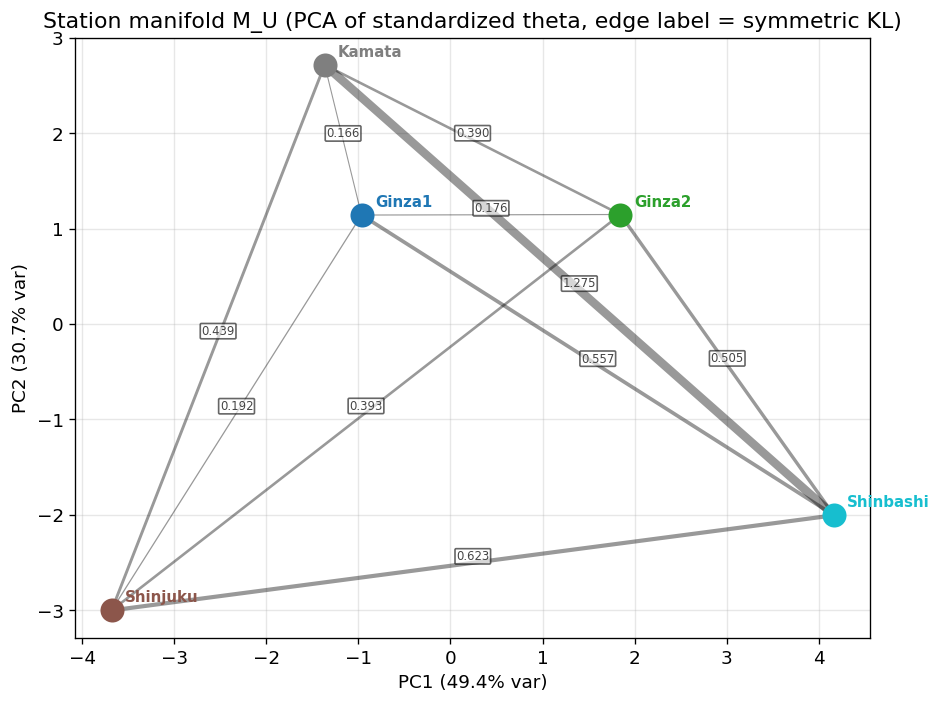

Explained variance: PC1=49.4%, PC2=30.7%, total=80.2%


In [62]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

theta_matrix = np.stack([station_theta[k] for k in keys])
theta_scaled = StandardScaler().fit_transform(theta_matrix)
pca = PCA(n_components=2)
coords_2d = pca.fit_transform(theta_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
colors = cm.tab10(np.linspace(0, 1, n))

for i, (key, coord) in enumerate(zip(keys, coords_2d)):
    ax.scatter(*coord, color=colors[i], s=180, zorder=5)
    ax.annotate(key, coord,
                textcoords='offset points', xytext=(8, 5),
                fontsize=9, color=colors[i], fontweight='bold')

for i, ki in enumerate(keys):
    for j, kj in enumerate(keys):
        if i < j:
            d = sym_kl[i, j]
            x_vals = [coords_2d[i,0], coords_2d[j,0]]
            y_vals = [coords_2d[i,1], coords_2d[j,1]]
            ax.plot(x_vals, y_vals, 'k-', alpha=0.4, lw=d * 4)
            mx, my = np.mean(x_vals), np.mean(y_vals)
            ax.text(mx, my, f'{d:.3f}', fontsize=7, ha='center', va='bottom',
                    color='#444', bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.6))

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
ax.set_title('Station manifold M_U (PCA of standardized theta, edge label = symmetric KL)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'manifold_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}, total={sum(pca.explained_variance_ratio_):.1%}')


In [64]:
from IPython.display import Markdown, display
import pandas as pd

rows = []
for i, ki in enumerate(keys):
    for j, kj in enumerate(keys):
        if i < j:
            pca_dist = np.linalg.norm(coords_2d[i] - coords_2d[j])
            kl_val   = sym_kl[i, j]
            rows.append({'Pair': f'{ki} vs {kj}', 'PCA dist': pca_dist, 'Sym-KL': kl_val})

df = pd.DataFrame(rows).sort_values('Sym-KL', ascending=False).reset_index(drop=True)

# Normalize each column to [0, 1]
df['PCA dist (norm)'] = (df['PCA dist'] - df['PCA dist'].min()) / (df['PCA dist'].max() - df['PCA dist'].min())
df['Sym-KL (norm)']   = (df['Sym-KL']   - df['Sym-KL'].min())   / (df['Sym-KL'].max()   - df['Sym-KL'].min())
df['diff (KL - PCA)'] = (df['Sym-KL (norm)'] - df['PCA dist (norm)']).round(3)

df_disp = df[['Pair', 'PCA dist', 'Sym-KL', 'PCA dist (norm)', 'Sym-KL (norm)', 'diff (KL - PCA)']].copy()
df_disp['PCA dist']      = df_disp['PCA dist'].round(3)
df_disp['Sym-KL']        = df_disp['Sym-KL'].round(3)
df_disp['PCA dist (norm)'] = df_disp['PCA dist (norm)'].round(3)
df_disp['Sym-KL (norm)']   = df_disp['Sym-KL (norm)'].round(3)

display(Markdown('### PCA distance vs Sym-KL divergence'))
display(Markdown('> Normalized to [0,1]. `diff > 0` means KL sees the pair as farther apart than PCA does.'))
display(df_disp)


### PCA distance vs Sym-KL divergence

> Normalized to [0,1]. `diff > 0` means KL sees the pair as farther apart than PCA does.

,Pair,PCA dist,Sym-KL,PCA dist (norm),Sym-KL (norm),diff (KL - PCA)
0,Kamata vs Shinbashi,7.272,1.275,0.899,1.000,0.101
1,Shinjuku vs Shinbashi,7.907,0.623,1.000,0.412,-0.588
2,Ginza1 vs Shinbashi,6.019,0.557,0.699,0.352,-0.347
3,Ginza2 vs Shinbashi,3.914,0.505,0.364,0.306,-0.059
4,Shinjuku vs Kamata,6.168,0.439,0.723,0.246,-0.477
5,Ginza2 vs Shinjuku,6.910,0.393,0.841,0.205,-0.636
6,Ginza2 vs Kamata,3.574,0.390,0.310,0.202,-0.108
7,Ginza1 vs Shinjuku,4.954,0.192,0.530,0.023,-0.507
8,Ginza1 vs Ginza2,2.811,0.176,0.189,0.009,-0.180
9,Ginza1 vs Kamata,1.624,0.166,0.000,0.000,0.000


## 13. Export

In [15]:
import os
(BASE_DIR / 'output' / 'manifold').mkdir(parents=True, exist_ok=True)

# Per-station distribution params
for key, fits in station_fits.items():
    out = {}
    for feat, info in fits.items():
        out[feat] = {
            'distribution': info['dist'],
            'params': list(info['params']),
            'n_tracks': info['n'],
            'theta': list(to_natural_params(feat, info['params'])),
            'eta':   list(to_expectation_params(feat, info['params'])),
        }
    path = BASE_DIR / 'output' / 'manifold' / f'{key}_dist_params.json'
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(out, f, ensure_ascii=False, indent=2)
    print(f"Saved: {path}")

# Combined manifold points CSV (one row per station)
rows = []
for key in keys:
    row = {
        'station': key,
        'name_ja': STATIONS[key]['name_ja'],
        'lat': STATIONS[key]['lat'],
        'lon': STATIONS[key]['lon'],
        'n_tracks': len(station_dfs[key]),
    }
    for feat, info in station_fits[key].items():
        for pi, p in enumerate(info['params']):
            row[f'{feat}_p{pi}'] = round(p, 6)
    rows.append(row)

manifold_df = pd.DataFrame(rows)
out_csv = BASE_DIR / 'output' / 'manifold' / 'manifold_points.csv'
manifold_df.to_csv(out_csv, index=False)
print(f"\nManifold points saved: {out_csv}")
print(f"Shape: {manifold_df.shape}")
manifold_df[['station', 'name_ja', 'n_tracks', 'lat', 'lon']].head()

Saved: ..\output\manifold\ginza1_dist_params.json
Saved: ..\output\manifold\ginza2_dist_params.json
Saved: ..\output\manifold\shinjuku_dist_params.json
Saved: ..\output\manifold\kamata_dist_params.json
Saved: ..\output\manifold\shinbashi_dist_params.json

Manifold points saved: ..\output\manifold\manifold_points.csv
Shape: (5, 30)


,station,name_ja,n_tracks,lat,lon
0,ginza1,銀座一丁目,618,35.67380,139.76772
1,ginza2,銀座二丁目,517,35.67385,139.76775
2,shinjuku,新宿,989,35.69183,139.70259
3,kamata,蒲田,745,35.66584,139.75795
4,shinbashi,新橋,1106,35.66575,139.75797
